<a href="https://colab.research.google.com/github/dtabuena/TabuenaJangGrone/blob/main/_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install openpyxl
!pip install XlsxWriter
!pip install pingouin
!pip install CMH
!pip install svgutils

from IPython.display import clear_output
import pandas as pd
import os
import numpy as np
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib
clear_output()

from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import scipy
# from pandas.compat.numpy import np_array_datetime64_compat
from random import sample
from tqdm import tqdm
import os
import shutil
from google import colab

from svgutils.compose import *

clear_output()




def restore_order(arg_ord):
    return np.argsort(arg_ord)

In [18]:
import urllib
response = urllib.request.urlretrieve('https://raw.githubusercontent.com/dtabuena/Resources/main/Matplotlib_Config/Load_FS6.py','Load_FS6.py')
%run 'Load_FS6.py'

Matplotlib_config load success
hue_seurat load failed


<Figure size 450x450 with 0 Axes>

In [19]:

def get_files(link):
    my_drop_folder = 'my_drop_folder'
    zipped_file_path = "/content/"+my_drop_folder + ".zip"
    unzipped_file_path = "/content/"+my_drop_folder
    if not( os.path.exists(zipped_file_path)):
        !wget -O $zipped_file_path $link    # download with new name
    !echo A | unzip $zipped_file_path -d $unzipped_file_path
    file_list = [f for r,d,f in os.walk("/content/"+my_drop_folder )][0]
    return file_list

def read_data_file(xl_to_analyze,dir='./Prelim_2023/Cleaned_DataSets/'):

    my_df_dict  = pd.read_excel(dir+xl_to_analyze, engine='openpyxl',index_col=None,sheet_name=None)

    NEW_my_df_dict = {}
    for k in my_df_dict.keys():
        new_k = k
        if 'cre' in new_k:
            new_k = k.replace('Syn1-cre','/Syn1-Cre')
        NEW_my_df_dict[new_k] = my_df_dict[k]

    return NEW_my_df_dict, xl_to_analyze

def dict_to_df(my_df_dict,AP_cut=60):
    '''convert dict of categories into a DF'''
    for k in my_df_dict.keys():
        df = my_df_dict[k]
        df['type'] = k
    df_list = [my_df_dict[k] for k in my_df_dict.keys()]
    full_df = pd.concat(df_list,ignore_index=True)

    '''drop low AP amps'''
    for r in full_df.index:
        if full_df.loc[r,'AP amp'] <AP_cut:
            full_df.at[r,'AP amp'] = np.nan
    return full_df

def clean_data(labeling,full_df):

    numericals = [c for c in full_df.columns if c not in labeling ]

    full_df_norm = full_df.copy()
    mean_dict = {}
    sd_dict = {}

    if 'extras' not in full_df.columns:
        exclude_extras = False
        plot_extras = False

    for c in full_df_norm.columns:
        if c not in labeling:
            col_mean = np.mean(full_df_norm[c])
            col_sd = np.std(full_df_norm[c])
            mean_dict[c] = col_mean
            sd_dict[c] = col_sd
            full_df_norm[c] = (full_df_norm[c] - col_mean)/col_sd


    null_check = pd.isna(full_df_norm)
    incomplete =[]
    for r in full_df_norm.index:
        vals = np.array(null_check.loc[r,numericals])
        bad = any(vals)
        if bad:
            incomplete.append(r)


    complete = [c for c in  full_df_norm.index if c not in incomplete]
    full_df_no_null = full_df_norm.loc[complete].copy()


    if exclude_extras:
        is_extra = list(full_df_no_null['extra']==1)
        extra_ind = full_df_no_null.index[is_extra]
        full_df_no_null.drop( index =extra_ind, inplace=True)


    data_X = full_df_no_null[numericals].to_numpy()
    data_for_fit = data_X
    numericals = [n.replace('(1)', '') for n in numericals]
    return numericals, data_for_fit, full_df_no_null

def get_types(full_df_no_null):
    type_list = list(full_df_no_null['type'])
    uniq_types = list(set(type_list))
    young_types = [t for t in uniq_types if '-9' in t and 'Cre' not in t]
    young_types.sort()
    cre_types = [t for t in uniq_types if 'Cre' in t]
    cre_types.sort()
    old_types = [t for t in uniq_types if '-19' in t and 'Cre' not in t]
    old_types.sort()
    uniq_types = young_types + cre_types + old_types
    # print(uniq_types)
    num_t = len(uniq_types)
    type_num = [ uniq_types.index(t) for t in type_list]
    return type_num, num_t, uniq_types,type_list

def cluster_full(data_for_fit,xl_to_analyze,labels):
    random_state = 42
    if 'CA1' in xl_to_analyze:
        random_state = 47
    if 'Type I ' in xl_to_analyze:
        random_state = 43
    if 'Type II ' in xl_to_analyze:
        random_state = 42


    rheo_ind = [i for i in range(len(labels)) if 'Rheo' in labels[i]][0]

    # kmeans = KMeans(n_clusters=2, random_state=random_state).fit(data_for_fit)
    needs_flip = True
    while needs_flip:
        random_state+=1
        print('random_state',random_state)
        kmeans = KMeans(n_clusters=2, random_state=random_state,n_init=10).fit(data_for_fit)
        centers = kmeans.cluster_centers_.T
        needs_flip = np.diff(centers[rheo_ind])<0
        print(np.diff(centers[rheo_ind]))

    # centers = kmeans.cluster_centers_.T
    distances = kmeans.transform(data_for_fit)
    rel_centers = (centers.T - np.mean(centers.T,axis = 0)).T


    labels = kmeans.labels_
    rel_counts = [np.mean( l == labels ) for l in range(2)]
    # new_cent_order = np.argsort(centers[:,0]).tolist()
    new_cent_order = np.arange(len(centers)).tolist()

    total_D = np.tile(np.sum(distances,axis=1),[2,1]).T
    closeness = np.log(total_D/distances)
    closeness = (closeness - np.mean(closeness,axis=0)) / (np.std(closeness,axis=0))
    distances_norm = (distances - np.mean(distances,axis=0)) / (np.std(distances,axis=0))
    score = closeness[:,1] - closeness[:,0]

    packaged = {'features':numericals,
                'kmeans':kmeans,
                'centers':centers,
                'distances':distances,
                'rel_centers':rel_centers,
                'rel_counts':rel_counts,
                'total_D':total_D,
                'closeness':closeness,
                'distances_norm':distances_norm,
                'score':-score,
                'data_for_fit':data_for_fit,
                'new_cent_order':new_cent_order
                }

    return packaged



def do_stats(type_list,score):
    is_E3 = ['E3' in t for t in type_list ]
    is_9mo = ['-19' not in t for t in type_list ]
    age_list = ['7-9' if b else '17-19' for b in is_9mo]
    genotype = ['apoE3-KI' if b else 'apoE4-KI' for b in is_E3]
    is_crePos = ['cre+' in t for t in type_list ]
    is_creNeg = ['cre-' in t for t in type_list ]
    not_cree = [not any( [is_crePos[i], is_creNeg[i]] ) for i in range(len(is_crePos))]
    e34_genotype = [genotype[i] for i in range(len(not_cree)) if not_cree[i]]
    e34_score = [score[i] for i in range(len(not_cree)) if not_cree[i]]
    e34_age = [str(age_list[i])+'mo' for i in range(len(not_cree)) if not_cree[i]]
    genotype_list_str = [t.replace(' 7-9mo', '').replace(' 17-19mo', '') for t in type_list]
    age_list_str = [str(a)+'mo' for a in age_list]

    df_for_34_2W_anova =  pd.DataFrame({'genotype': genotype_list_str,  'Age': age_list_str,'T1_Score': score})


    ANOVA2_results = pg.anova(dv='T1_Score', between=['genotype', 'Age'], data=df_for_34_2W_anova, detailed=True)
    # display(ANOVA2_results)

    ANOVA2_results.to_csv(f'{folder}/2W_results Age-Geno.csv')
    df_for_34_2W_anova['combination'] = df_for_34_2W_anova.genotype + " " + df_for_34_2W_anova.Age
    m_comp = pairwise_tukeyhsd(endog=df_for_34_2W_anova['T1_Score'], groups=df_for_34_2W_anova['combination'], alpha=0.05)
    tukey_data = pd.DataFrame(data=m_comp._results_table.data[1:], columns = m_comp._results_table.data[0])
    tukey_data = tukey_data.sort_values('p-adj',ascending=True)
    # display(tukey_data)

    tukey_data.to_csv(f'{folder}/pairwise Age-Genotype.csv')
    df_for_34_2W_anova.to_csv(f'{folder}/Scores.csv')
    return df_for_34_2W_anova, tukey_data


def save_dl(folder):
    root_list = []
    f_list = []

    fold_name = folder
    fold_name = fold_name.replace(' ','_')
    zip_name= fold_name+'.zip'

    print(folder)
    !zip -r $zip_name $folder
    colab.files.download(zip_name)
    return None



In [20]:
def plot_summary(num_t,numericals,type_list,uniq_types,packaged,df_for_34_2W_anova,tukey_data,folder, clust_names = ['Hyper', 'Normal'],fig_opt = {'dpi': 300, 'format':'png','bbox_inches':None}):

    cmap = plt.cm.cool(np.linspace(0,1,2))*np.array([0.6]*3+[1])
    dark_cool = mpl.colors.ListedColormap(cmap)
    dpi=300

    kmeans = packaged['kmeans']
    centers = packaged['centers']
    distances = packaged['distances']
    rel_centers = packaged['rel_centers']
    rel_counts = packaged['rel_counts']
    total_D = packaged['total_D']
    closeness = packaged['closeness']
    distances_norm = packaged['distances_norm']
    score = packaged['score']
    data_for_fit = packaged['data_for_fit']
    cell_type = packaged['cell_type']
    type_num = packaged['type_num']

    colors = plt.cm.viridis(np.linspace(0,1,num_t))
    alpha_1 = 1
    alpha_2 = .8
    colors = [[4/255, 51/255, 255/255, alpha_1], [4/255, 51/255, 255/255, alpha_2],
              [255/255, 38/255, 0/255, alpha_1], [255/255, 38/255, 0/255, alpha_2],
            #   [223/255, 142/255, 32/255, alpha_1], [242/255, 210/255, 166/255, alpha_2], # ORANGES
                [103/255, 35/255, 2/255, alpha_1], [103/255, 35/255, 2/255, alpha_2], # BROWNS
              ]


    list_colors = [colors[i] for i in type_num ]
    color_dc={'apoE3-KI 7-9mo': colors[0],
                'apoE3-KI 17-19mo': colors[1],
                'apoE4-KI 7-9mo':colors[2],
                'apoE4-KI 17-19mo': colors[3],
                'fE4/Syn1-Cre+ 7-9mo': colors[4],
                'fE4/Syn1-Cre- 7-9mo': colors[5],}


    ################# raw_data_map '''
    counts = [np.sum( [tt==t for tt in type_list]) for t in uniq_types ]
    counts[-1] = counts[-1] +  np.sum(counts)*0.075
    fig_norm_vals, ax = plt.subplots(1,num_t+1,figsize = [7.25,1.6],gridspec_kw={'width_ratios': counts+[.75]},layout="constrained",dpi=dpi)
    data_X_min = np.min(data_for_fit)
    data_X_max = np.max(data_for_fit)
    extrema = np.array([-1,1]) * np.max(np.abs([data_X_min,data_X_max]))
    data_X_min = extrema[0]
    data_X_max = extrema[1]

    for ti in range(num_t):
        t = uniq_types[ti]
        t_colr = colors[ti]
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        c = ax[ti].pcolor(data_for_fit.T[:,is_type], vmin=data_X_min*1.2, vmax=data_X_max*1.2)
        ax[ti].set_yticks(np.arange(len(numericals))+0.5)
        if ti ==0 : ax[ti].set_yticklabels(numericals,rotation=0)
        else:  ax[ti].get_yaxis().set_visible(False)
        if ti==0: ax[ti].set_xlabel('Cell (#)')
        ax[ti].title.set_text(t.replace(' ','\n'))
        start = min(is_type)+3 / len(is_type)
        stop = max(is_type)-3 / len(is_type)
    fig_norm_vals.suptitle(cell_type+ ' Normalized Parameters',y=1.05,)#  fontsize=6

    plt.colorbar(c, cax=ax[ti+1],label='z-scored'+'\n'+'values')
    plt.show()
    # plt.tight_layout()


    # plt.rcParams.update({'font.size': FS,'font.family': 'arial'}) #14


    ################# Centers
    new_cent_order = np.argsort(centers[:,1]).tolist()[::-1]
    fig_centers, ax = plt.subplots(1,1,figsize = [3,2],dpi=dpi,layout="constrained")
    ax.set_prop_cycle(color=[cmap[0], cmap[1]])
    ax.plot(centers[new_cent_order,:],'-o',linewidth=.5,markersize=2)
    ax.legend(clust_names,loc='lower center',frameon=False)
    sorted_numericals = [numericals[i] for i in new_cent_order]
    ax.set_xticks(np.arange(len(numericals)))
    ax.set_xticklabels(sorted_numericals,rotation=45,ha='right', rotation_mode='anchor')
    ax.set_ylabel('z-scored'+' '+'values')
    ax.axhline(0,color='k',linewidth=1)
    ax.title.set_text(cell_type +' '+'Cluster Centers')
    # plt.tight_layout()

    ################# Split Distance heat map
    counts = [np.sum( [tt==t for tt in type_list]) for t in uniq_types ]
    print(counts)
    b_dim = 2
    fig_distances_split, ax = plt.subplots(1,num_t+1,figsize = [7.25,.9],gridspec_kw={'width_ratios': counts+[.75]},layout="constrained",dpi=dpi) ## NEw
    dist_min = np.min(distances_norm)
    dist_max = np.max(distances_norm)

    extrema = np.array([-1,1]) * np.max(np.abs([dist_min,dist_max]))
    dist_min = extrema[0]
    dist_max = extrema[1]

    # plt.rcParams.update({'font.size': FS,'font.family': 'arial'}) #14
    for ti in range(num_t):
        t = uniq_types[ti]
        t_colr = colors[ti]
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        c = ax[ti].pcolor(distances_norm.T[:,is_type], vmin=dist_min*1.2, vmax=dist_max*1.2)
        ax[ti].set_yticks(np.arange(len(clust_names))+0.5)
        clust_names_nl = [c.replace(' ',' ') for c in clust_names]
        if ti ==0 : ax[ti].set_yticklabels(clust_names_nl,rotation=0)
        else:  ax[ti].get_yaxis().set_visible(False)
        if ti==0: ax[ti].set_xlabel('Cell (#)')
    # fig_distances_split.tight_layout()
    fig_distances_split.colorbar(c, cax=ax[ti+1],label='z-scored'+'\n'+'distance')
    for ti in range(num_t):
        t = uniq_types[ti]
        ax[ti].text(0.5, 1, t.replace(' ','\n'),transform=ax[ti].transAxes,ha='center',rotation=0,va='bottom') # ,fontsize=14
    # fig_distances_split.tight_layout()
    plt.show()


    ############# Combined Scatter
    # plt.rcParams.update({'font.size': FS,'font.family': 'arial'}) #14
    fig_comb_scatter, ax = plt.subplots(1,figsize = [7.25/5,7.25/5],dpi=dpi,layout="constrained")
    for ti in range(num_t):
        t = uniq_types[ti]
        t_colr = color_dc[t]
        print(t,t_colr)
        t_colr_edge = t_colr[:-1] + [alpha_1]
        t_colr_edge = None
        t_colr = 'k'
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        ax.scatter(distances_norm[is_type,0],distances_norm[is_type,1],color=t_colr, label=t,linewidth=1,edgecolor=t_colr_edge,s=2,zorder=1)
    # ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_xlabel('Dist. from '+clust_names[0]+' Center \n (z-scored)')
    ax.set_ylabel('Dist. from '+clust_names[1]+' Center \n (z-scored)')
    ax.plot([0, 1], [0, 1], transform=ax.transAxes,color='k',linewidth=1)
    ax.text(0.98, 0.02, ''+clust_names[1],transform=ax.transAxes,ha='right',va='bottom') # ,fontsize=12
    ax.text(0.02, 0.98, ''+clust_names[0],transform=ax.transAxes,ha='left',va='top') # ,fontsize=12
    comb_xlim = ax.get_xlim()
    comb_ylim = ax.get_ylim()
    common_lim = np.array([-1,1]) * np.max(np.abs(list(comb_xlim)+list(comb_ylim)))
    common_lim= [np.min([comb_xlim[0],comb_ylim[0]]), np.max([comb_xlim[1],comb_ylim[1]]) ]
    ax.set_xlim(common_lim)
    ax.set_ylim(common_lim)

    # residuals = np.diff(distances_norm,axis=1)
    x=distances_norm[:,0]
    y=distances_norm[:,1]
    for i in range(len(x)):
        if x[i]>y[i]:
            c=[.6,  0, .6]
        else :
            c=[0,  .6, .6]
        plt.plot([x[i], x[i]], [y[i], x[i]], color=c, linewidth=0.5,zorder=-1)

    #### separate Scatter #####
    b_dim = 3
     #14

    print(common_lim)
    common_lim =common_lim+np.array([0,2])
    """ for horizontal scatter Layout """
    # if 'CA3' in cell_type: fig_sep_scatter, axs = plt.subplots(1,num_t,figsize = [7.25,7.25/num_t*1.2],dpi=dpi,layout="constrained") #
    # else: fig_sep_scatter, axs = plt.subplots(2,int(num_t/2),figsize =[7.25/3*.9,7.25/3*1],dpi=dpi,layout="constrained") #  [int(num_t/2)*b_dim,b_dim*2]

    """ for compact scatter Layout """
    if 'CA3' in cell_type: fig_sep_scatter, axs = plt.subplots(3,int(num_t/3),figsize = [7.25/4,7.25/4*1.5*1.2],dpi=dpi,layout="constrained") #
    else: fig_sep_scatter, axs = plt.subplots(2,int(num_t/2),figsize =[7.25/4,7.25/4*1.2],dpi=dpi,layout="constrained") #  [int(num_t/2)*b_dim,b_dim*2]

    axs = axs.T.flatten()
    if 'CA3' in cell_type:
       axs = axs[np.arange(6)[[0,1,2,5,3,4]]]

    for ti in np.arange(num_t):
        t = uniq_types[ti]
        t_colr = color_dc[t]
        t_colr_edge = t_colr[:-1] + [alpha_1]
        t_colr_edge = None
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        axs[ti].scatter(distances_norm[is_type,0],distances_norm[is_type,1],color=t_colr, label=t,linewidth=1,edgecolor=t_colr_edge,s=2)
        axs[ti].plot([0, 1], [0, 1], transform=axs[ti].transAxes,color=[0,0,0,1],linewidth=1)
        axs[ti].title.set_text(t.replace(' ','\n').replace('apo',""))
        axs[ti].set_xlim(common_lim)
        axs[ti].set_ylim(common_lim)

        axs[ti].text(0.98, 0.02, ''+clust_names[1],transform=axs[ti].transAxes,ha='right',va='bottom')
        axs[ti].text(0.02, 0.98, ''+clust_names[0],transform=axs[ti].transAxes,ha='left',va='top')

    # bot_left = len(axs)//2-1
    # axs[bot_left].set_xlabel(clust_names[0]+' Dist.', color='black')
    # axs[bot_left].set_ylabel(clust_names[1]+' Dist.', color='black')
    fig_sep_scatter.subplots_adjust(wspace=0.3, hspace=0.3)
    fig_sep_scatter.supxlabel(f'{clust_names[0]} Distance', x=0.60,y=.05)
    fig_sep_scatter.supylabel(f'{clust_names[1]} Distance', x=0.050)
    plt.tight_layout()




    ########  ''' Violins of Residual Plots '''
    if 'CA3' in cell_type: fig_violin_residuals, ax = plt.subplots(1,figsize=np.array([7.25*.3,2.25]),dpi=dpi,layout="constrained")
    else: fig_violin_residuals, ax = plt.subplots(1,figsize=np.array([7.25*.7/3,2.25]),dpi=dpi,layout="constrained")

    comb_list = list(set(df_for_34_2W_anova['combination']))

    young_types = [t for t in comb_list if '-9' in t and 'Cre' not in t]
    young_types.sort()
    cre_types = [t for t in comb_list if 'Cre' in t]
    cre_types.sort()
    old_types = [t for t in comb_list if '-19' in t and 'Cre' not in t]
    old_types.sort()
    comb_list = young_types + cre_types + old_types

    sns_dict={}



    for ti in range(len(comb_list)):
        type_i = comb_list[ti]
        match_type = df_for_34_2W_anova['combination']==type_i
        y_vals = list(np.array(df_for_34_2W_anova[match_type]['T1_Score']))
        x_vals = np.ones_like(y_vals)*ti + int(np.floor(ti/2))
        pos = list(np.ones_like(y_vals)*ti)
        t_colr = colors[ti]
        t_colr = color_dc[type_i]
        sns_dict[type_i] =y_vals

    # print(sns_dict.keys())
    sns_df =  pd.DataFrame.from_dict(sns_dict, orient='index').T
    # display(sns_df.head())

    colors_sns = [color_dc[t] for t in sns_df.columns]
    # colors_sns = [color_dc[k] for k in color_dc.keys()]
    colors_sns = [ list(np.array(c[:-1]) + (1 - np.array(c[:-1]))* (1-c[-1])) + list(c[-1:]) for c in  colors_sns]

    sns.swarmplot(ax=ax,data=sns_df,palette=colors_sns, label=t,linewidth=.05,edgecolor='k',size=2) # color='k'
    sns.violinplot(ax=ax,data=sns_df,palette=colors_sns,scale ='area', label=t, linewidth=1,inner=None)
    # Manually adjust the violins
    violins = [v for v in ax.collections if isinstance(v, matplotlib.collections.PolyCollection)]  # Get all violins
    for i, violin in enumerate(violins):
        violin.set_facecolor([0.9, 0.9, 0.9])  # Set the fill color to light gray
        violin.set_edgecolor(colors_sns[i % len(colors_sns)])  # Set edge color using colors_sns
        violin.set_linewidth(1)  # Set the linewidth to make the edges more visible

    ax.text(0, 1, clust_names[0],transform=ax.transAxes,ha='right',va='bottom',color=[0, .6, .6])
    ax.text(0, 0, clust_names[1],transform=ax.transAxes,ha='right',va='top',color=[.6,  0, .6])

    ax.set_ylabel('Residual Value')
    ax.set_ylim(-7.5,12.5)
    ax.axhline(0,color='k',linewidth=.5)
    ax_labels = sns_df.columns
    ax.set_xticks(ticks=range(len(ax_labels)))
    ax_labels_r = [c.replace(' ','\n') for c in ax_labels]
    ax_labels_r = [c.replace('\nsyn',' syn') for c in ax_labels_r]
    ax_labels_r = [c.split('\n')[0]  for c in ax_labels_r]
    ax_labels_r = [c.replace('fE4/Syn1-Cre', 'Cre') for c in ax_labels_r]
    ax_labels_r = [c.replace('apo', '') for c in ax_labels_r]
    # ax_labels_r = ['\n'+ax_labels_r[i] if i%2 == 0 else ax_labels_r[i] for i in range(len(ax_labels_r)) ]


    # ax.set_xticklabels(ax_labels_r,rotation=60,ha='right', va='top', rotation_mode='anchor')
    ax.set_xticklabels(ax_labels_r,rotation=0,ha='center', va='top', rotation_mode='anchor')
    ax.title.set_text(cell_type) #+' Cluster Membership'

    div_x = np.sum( ['7-9' in l for l in ax_labels])-0.5
    segment_x = [div_x, div_x]
    segment_y = ax.get_ylim()*np.array([1,1])
    ll = plt.plot(segment_x,segment_y,':k',linewidth=.5) # returns a sequence of line objects
    ll[0].set_clip_on(False)
    month_offset = 0 # 10
    plt.text(div_x/2-0.25, segment_y[0]-month_offset, '7-9mo',ha='center',va='bottom')
    plt.text(div_x+1, segment_y[0]-month_offset, '17-19mo', ha='center',va='bottom')
    print('sns_dict',sns_dict)

    cre_ind = [i for i,k in enumerate(sns_dict.keys()) if 'Cre' in k]
    if len(cre_ind)>0:
        x = np.mean(cre_ind)
        plt.text(x, segment_y[0]-4, 'fE4/Syn-Cre',ha='center',va='bottom')
    else:
        plt.text(1, segment_y[0]-4, 'PLACE HOLDER' ,ha='center',va='bottom', color = 'white')

    base_offset = 1.5
    y0 = np.max(df_for_34_2W_anova['T1_Score'])*base_offset
    print('y0',y0)
    labels = comb_list
    true_tuckey = tukey_data[tukey_data['reject']==True]

    astk_range = [0.05,0.01,0.001,0.0001]
    for r in true_tuckey.index:
        comps = ['apoE3-KI 7-9mo']
        if true_tuckey.loc[r,'group1'] in comps or true_tuckey.loc[r,'group2'] in comps:
            start_l = true_tuckey.loc[r,'group1']
            stop_l = true_tuckey.loc[r,'group2']
            start_x = labels.index(start_l)
            stop_x = labels.index(stop_l)
            y0 = np.max(df_for_34_2W_anova['T1_Score'])*base_offset - 1
            y_offset = abs((stop_x-start_x))
            y = y0+ y_offset * 1.25 + np.min([stop_x,start_x])*.25

            half_dx = abs(stop_x-start_x)/2
            ax.errorbar( np.mean([stop_x,start_x]), y,yerr=0, xerr=half_dx,color='k',capsize=.75,linewidth=0.75,capthick=0.75)

            cent =np.mean([start_x,stop_x])
            num_ask = np.sum([true_tuckey.loc[r,'p-adj'] < t for t in astk_range] )

            plt.text(cent,y, '*' * num_ask,ha='center',va='center',fontsize = 2+plt.rcParams['font.size'])


        if 'Syn' in true_tuckey.loc[r,'group1'] and 'Syn' in true_tuckey.loc[r,'group2']:
            start_l = true_tuckey.loc[r,'group1']
            stop_l = true_tuckey.loc[r,'group2']
            start_x = labels.index(start_l)
            stop_x = labels.index(stop_l)
            y0 = np.max(df_for_34_2W_anova['T1_Score'])*base_offset
            y_offset = abs((stop_x-start_x))
            y = y0+ y_offset * .75

            half_dx = abs(stop_x-start_x)/2
            ax.errorbar( np.mean([stop_x,start_x]), y,yerr=0, xerr=half_dx,color='k',capsize=.75,linewidth=0.75,capthick=0.75)

            cent =np.mean([start_x,stop_x])
            num_ask = np.sum([true_tuckey.loc[r,'p-adj'] < t for t in astk_range] )
            print(true_tuckey.loc[r,'p-adj'],num_ask)
            plt.text(cent,y, '*' * num_ask,ha='center',va='center',fontsize = 2+plt.rcParams['font.size'])

    plt.tight_layout()


    fig_norm_vals.savefig(f'{folder}/Normalized_Vals_split.'+fig_opt['format'],**fig_opt)
    fig_violin_residuals.savefig(f'{folder}/fig_violin_residuals.'+fig_opt['format'],**fig_opt)
    fig_distances_split.savefig(f'{folder}/fig_distances_split.'+fig_opt['format'],**fig_opt)
    # fig_centers.savefig(f'{folder}/centers.'+fig_opt['format'],**fig_opt)
    # fig_pie.savefig(f'{folder}/pie.'+fig_opt['format'],**fig_opt)
    fig_sep_scatter.savefig(f'{folder}/GenoType_dist_Separate.'+fig_opt['format'],**fig_opt)
    fig_comb_scatter.savefig(f'{folder}/GenoType_dist.'+fig_opt['format'],**fig_opt)
    # fig_sep_hist.savefig(f'{folder}/GenoType_Histos.'+fig_opt['format'],**fig_opt)
    return None




### Testing

# plot_summary(num_t,numericals,type_list,uniq_types,packaged,df_for_34_2W_anova,tukey_data,folder,fig_opt =fig_opt)


/tmp/ipython-input-3638927628.py:65: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig_cartoon.savefig('./fig_cartoon_x.' + fig_opt['format'], **fig_opt)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


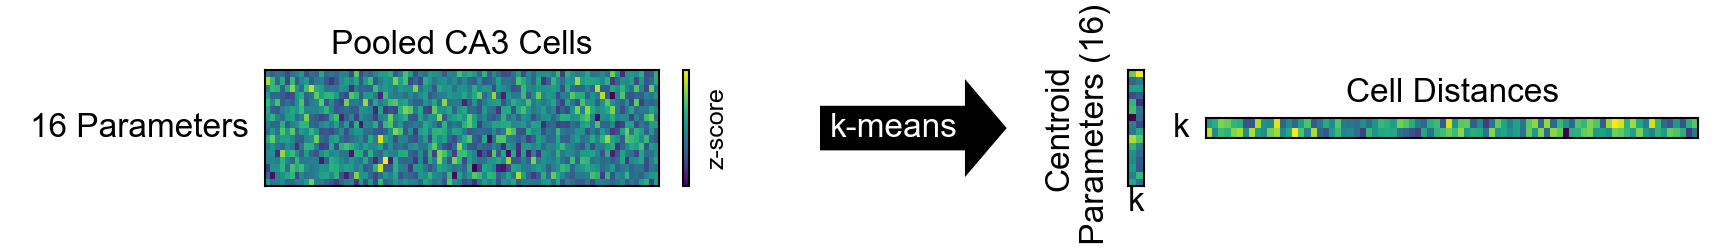

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrow

def fig_cartoon_x(fig_opt={'dpi': 300, 'format': 'svg', 'bbox_inches': None}):
    FS = 8
    A = np.random.randn(16, 80)
    B = np.random.randn(2, 80)
    B_t = np.random.randn(16, 2)

    fig_cartoon, ax = plt.subplots(3, 4, figsize=[7.25 * .85, .5], width_ratios=[6, 3, .2, 6], height_ratios=[4, 2, 4], dpi=300, layout="constrained")

    # Hide the original axes
    for a in ax.reshape(-1):
        a.set_visible(False)

    # Get the gridspec to modify the layout
    gs = ax[0, 0].get_gridspec()

    # Create the large axis for the heatmap A
    big_ax_1 = fig_cartoon.add_subplot(gs[0:, 0])
    ch = big_ax_1.pcolorfast(A)
    cbar = plt.colorbar(ch)
    cbar.set_ticks([])
    cbar.set_label('z-score')
    big_ax_1.set_xlabel('Pooled CA3 Cells', fontsize=FS)
    big_ax_1.set_ylabel('16 Parameters', rotation=0, ha='right', va='center', fontsize=FS)
    big_ax_1.xaxis.set_label_position('top')
    big_ax_1.set_xticks([])
    big_ax_1.set_yticks([])

    # Create an axis for B (second row, fourth column)
    ax[1, 3].set_visible(True)
    ax[1, 3].pcolorfast(B)
    ax[1, 3].set_ylabel('k', rotation=0, ha='right', va='center', fontsize=FS)
    ax[1, 3].set_title('Cell Distances', rotation=0, ha='center', va='center', fontsize=FS)
    ax[1, 3].set_xticks([])
    ax[1, 3].set_yticks([])

    # Create the third large axis for B_t
    big_ax_2 = fig_cartoon.add_subplot(gs[0:, 2])
    big_ax_2.pcolorfast(B_t)
    big_ax_2.set_xlabel('k', rotation=0, ha='center', va='center', fontsize=FS)
    big_ax_2.set_ylabel('Centroid\n Parameters (16)', rotation=90, ha='center', va='bottom', fontsize=FS)
    big_ax_2.set_xticks([])
    big_ax_2.set_yticks([])

    # Create a new axis for the blocky arrow, spanning only the second column
    arrow_ax = fig_cartoon.add_subplot(gs[:, 1])  # this spans the whole second column
    arrow_ax.set_xticks([])
    arrow_ax.set_yticks([])
    arrow_ax.set_frame_on(False)  # Hide the axis frame
    arrow_ax.set_xlim(-.0,1.2)

    # Add the blocky arrow on the new axis
    x_start, y_start = 0, 0.5  # Arrow starting position in axes coordinates
    dx, dy = 0.6, 0  # Arrow length (horizontal)
    arrow = FancyArrow(x_start, y_start, dx, dy, width=.35, head_width=0.75, head_length=0.15, color='k', transform=arrow_ax.transAxes)
    arrow_ax.add_patch(arrow)

    # Add label for the arrow
    arrow_ax.annotate('k-means', xy=(x_start + dx / 2, y_start), ha='center', va='center', xycoords='axes fraction', color='w', fontsize=FS)

    # Save the figure
    fig_cartoon.savefig('./fig_cartoon_x.' + fig_opt['format'], **fig_opt)

    return None

fig_cartoon_x()


In [22]:
def cross_val(data_for_fit,numericals,new_cent_order,folder,k=2,
              num_iter = 1000,SubSampleFrac = .8,cell_type='',fig_opt = {'dpi': 300, 'format':'svg','bbox_inches':None},ds_iter=10):

    cval_res = {}
    center_list = []
    label_list = []
    sub_sample_ind_list = []
    full_label_list = []
    pred_all = True
    # sorted_numericals = [numericals[i] for i in new_cent_order]

    FS=6
    dpi=300

    # set_font_all(FS)

    cmap = plt.cm.cool(np.linspace(0,1,k))*np.array([0.6]*3+[1])
    dark_cool = mpl.colors.ListedColormap(cmap)

    for ni in tqdm( range(num_iter) ):
        sub_sample_ind = []
        for t in uniq_types:
            t_inds = [i for i in range(len(type_list)) if t in type_list[i]]
            # print(t_inds)
            sub_sample_ind.extend( sample(t_inds, int(len(t_inds)*SubSampleFrac) ) )
        kmeans_iter = KMeans(n_clusters=k, random_state=42,n_init=10).fit(data_for_fit[sub_sample_ind][:,new_cent_order])
        centers_iter = kmeans_iter.cluster_centers_.T
        centers_iter = centers_iter - np.mean(centers_iter,axis=0)
        labels_iter = kmeans_iter.labels_
        if pred_all:
            labels_iter = kmeans_iter.predict(data_for_fit)

        if ni>0:
            corco = np.corrcoef(centers_iter.T,center_list[0].T)
            corco = corco[0:k,k:]
            ind = np.argmax(corco,axis=0)
            centers_iter = centers_iter[:,ind]
            labels_iter = [ind[l] for l in labels_iter]

        if not pred_all:
            full_label_iter = np.empty((data_for_fit.shape[0],))
            full_label_iter[:] = np.nan
            full_label_iter[sub_sample_ind] = labels_iter
        else:
            full_label_iter = labels_iter

        center_list.append(centers_iter)
        label_list.append(labels_iter)
        sub_sample_ind_list.append(sub_sample_ind_list)
        full_label_list.append(full_label_iter)

    center_stack = np.stack(center_list)
    mean_center = np.mean(center_stack,0)
    nintey_p_center = np.percentile(center_stack, [.5, 99.5], axis=0)

    cval_res['mean_center'] = mean_center
    cval_res['confidence'] = nintey_p_center


    plot_order = np.argsort(np.diff(mean_center,1).T)[0]
    numericals=np.array(numericals)

    ####### PLOT CENTERS
    plt.rcParams.update({'font.size': FS,'font.family': 'arial'}) #14
    fig_cv_cent, ax = plt.subplots(1,figsize = (7.25/4,1.8),dpi=dpi,layout="constrained")

    handle_list = []
    if k == 2:
        clust_names = [ 'Hyper', 'Normal']
        rheo_index_in_center = [i for i in range(len(numericals)) if 'Rheo' in numericals[i]]
        rheo_dif = np.diff(mean_center[rheo_index_in_center,:])[0]
        if rheo_dif<0:
            clust_names=clust_names[::-1]
            cmap=np.flipud(cmap)

    for ki in range(k):
        if k==2: ax.plot(mean_center[plot_order,ki].T,'-o',color=cmap[ki],linewidth=1,label = clust_names[ki],markersize=2)
        else: ax.plot(mean_center[plot_order,ki].T,'-o',color=cmap[ki],linewidth=.5,markersize=2)
        ax.plot(nintey_p_center[0,plot_order,ki].T,':',color=cmap[ki],linewidth=.5)
        ax.plot(nintey_p_center[1,plot_order,ki].T,':',color=cmap[ki],linewidth=.5)

    ax.set_xticks(np.arange(len(numericals)))
    ax.set_xticklabels(numericals[plot_order],rotation=45,ha='right',va='center', rotation_mode='anchor',fontsize=plt.rcParams['font.size']) # ,fontsize=14
    ax.axhline(0, color='k',linewidth=.5)

    if k == 2: ax.legend(loc='upper center',frameon=False,fontsize=plt.rcParams['font.size'])
    ax.set_ylabel('z-scored'+' '+'values')


    full_label_stack = np.stack(full_label_list)

    pseudo_truth = scipy.stats.mode(full_label_stack,axis=0, nan_policy='omit')[0]
    is_match = (full_label_stack == pseudo_truth)*1. # convert to float so can accept nans
    is_match[np.isnan(full_label_stack)]=np.nan
    consistency_iter = np.nanmean(is_match, axis = 1)
    mean_consistency_iter = np.nanmean(consistency_iter)
    std_consistency_iter = np.nanstd(consistency_iter)
    consistency_cell = np.nanmean(is_match, axis = 0)
    mean_consistency_cell = np.nanmean(consistency_cell)
    sd_consistency_cell = np.nanstd(consistency_cell)
    consistency_report = 'label consistency: ' + str(round(mean_consistency_cell*100,1)) + '% +- ' + str(round(sd_consistency_cell*100,2)) + ' (chance: ' + str(round(1/k*100,1))+')'
    ax.title.set_text(cell_type)


    cval_res['mean_consistency_iter'] = mean_consistency_iter
    cval_res['std_consistency_iter'] = std_consistency_iter
    cval_res['consistency_cell'] = consistency_cell
    cval_res['mean_consistency_cell'] = mean_consistency_cell

    plt.tight_layout()
    fig_cv_cent.tight_layout()
    fig_cv_cent.patch.set_facecolor('white')

    plt.show()
    fig_cv_cent.savefig(f'{folder}/CrossVal_Data k={k} Centers.'+fig_opt['format'],**fig_opt)


    ################## Plot iteration results
    scale_factor= 1
    plt.rcParams.update({'font.size': FS*scale_factor, 'font.family': 'arial'})
    fig_cv_prob, ax = plt.subplots(2,2,figsize=np.array([7.25/4,1.8]),
                                   gridspec_kw={'height_ratios': [3, 1],'width_ratios': [4, 1.1]}  ,dpi=dpi,layout="constrained")

    ax  = ax.T.flatten()

    iters_ds = np.arange(0, num_iter + 1, ds_iter)
    cell_ids = np.arange(0, full_label_stack.shape[1] + 1)   # **Use shape[1] for cells**
    pcol = ax[0].pcolorfast(cell_ids, iters_ds, full_label_stack[::ds_iter,:], cmap=dark_cool)  # **Swap arguments**


    ax[0].set_xlabel('Cell (#)\n',va='bottom')
    ax[0].set_ylabel('Iteration (#)\n',va='bottom',rotation = 90)
    ax[0].xaxis.set_label_position('top')
    # ax[0].set_xticks([])
    ax[0].xaxis.tick_top()

    ax[1].scatter(np.arange(len(consistency_cell)),consistency_cell*100,color='k',s=1,edgecolor='k',marker='.')
    ax[1].axhline(1/k*100,color='k',linestyle=':',linewidth=.25)
    ax[1].set_ylabel('Cell\nConsistency (%)',va='bottom',rotation = 90)
    ax[1].set_ylim((0,102))
    ax[1].set_xlim((0,is_match.shape[1]))
    ax[1].set_xlabel('Cell (#)')

    ax[2].scatter(consistency_iter*100,np.arange(num_iter),color='k',s=1,edgecolor='k',marker='.')
    ax[2].axvline(1/k*100,color='k',linestyle=':',linewidth=.25)
    ax[2].set_xlabel('Iteration\nConsistency (%)',va='bottom')
    ax[2].set_xlim((102,0))
    ax[2].set_ylim((0,num_iter))
    ax[2].yaxis.tick_right()
    ax[2].xaxis.set_label_position('top')
    ax[2].xaxis.tick_top()


    # fig.delaxes(ax[3])
    ax[3].errorbar(mean_consistency_iter*100, mean_consistency_cell*100, yerr=sd_consistency_cell*100, xerr=std_consistency_iter*100,color='k',capsize=.75,linewidth=0.5,capthick=0.5)
    ax[3].axvline(1/k*100,color='k',linestyle=':',linewidth=.25)
    ax[3].axhline(1/k*100,color='k',linestyle=':',linewidth=.25)
    ax[3].set_xlim((100,0))
    ax[3].set_ylim((0,100))
    ax[3].yaxis.tick_right()

    # fig_cv_prob.suptitle(f'k = {k} clusters', y=1.3,fontsize=plt.rcParams['font.size'])#  y=1.075

    # fig_cv_prob.tight_layout(pad=.1)
    # fig_cv_prob.set_figwidth(1.8)
    # fig_cv_prob.set_figheight(1.6)
    ax[0].set_xticks([])

    fig_cv_prob.patch.set_facecolor('white')

    plt.show()

    plt.tight_layout()

    fig_cv_prob.savefig(f'{folder}/CrossVal_Data k={k} Labeling.'+fig_opt['format'],**fig_opt)



    return cval_res




In [23]:
### Git clone data tables for sorting ###
try: shutil.rmtree('./'+git_rep)
except: None
git_rep = 'Prelim_2023'
git_link = 'https://github.com/dtabuena/'+git_rep+'/'
!git clone $git_link
file_list = [f for f in [f for r,d,f in os.walk('./'+git_rep+'/Cleaned_DataSets/' )][0] if '.xlsx' in f]
print(file_list)
mpl.font_manager.fontManager.addfont('./'+git_rep+'/Cleaned_DataSets/arial.ttf')

Cloning into 'Prelim_2023'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 190 (delta 39), reused 0 (delta 0), pack-reused 114 (from 1)
Receiving objects: 100% (190/190), 64.65 MiB | 14.54 MiB/s, done.
Resolving deltas: 100% (88/88), done.
['CA1 main parameters_Clean.xlsx', 'CA3 parameters for PCA_Clean.xlsx', 'DG Type I GC main parameters_Clean.xlsx', 'DG Type II GC main parameters_Clean.xlsx']


/tmp/ipython-input-3638927628.py:65: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig_cartoon.savefig('./fig_cartoon_x.' + fig_opt['format'], **fig_opt)


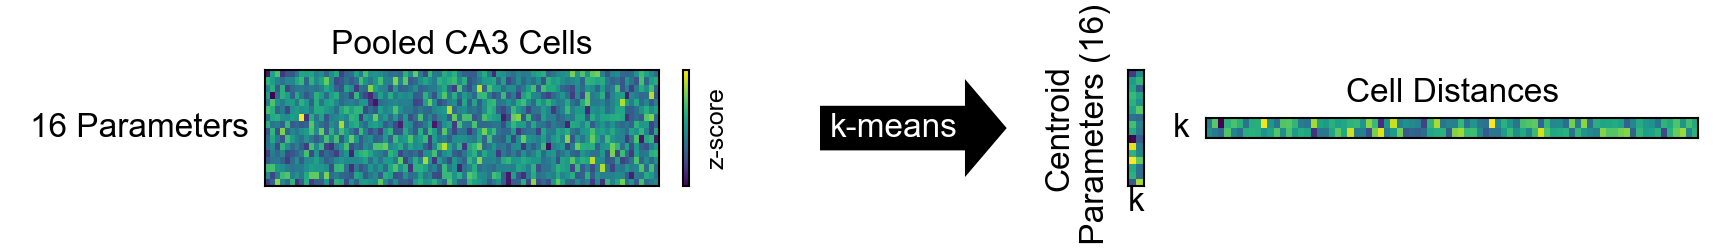

In [24]:
fig_cartoon_x(fig_opt={'dpi': 300, 'format':'svg','bbox_inches':None})

random_state 48
[-0.91829798]
random_state 49
[0.91829798]


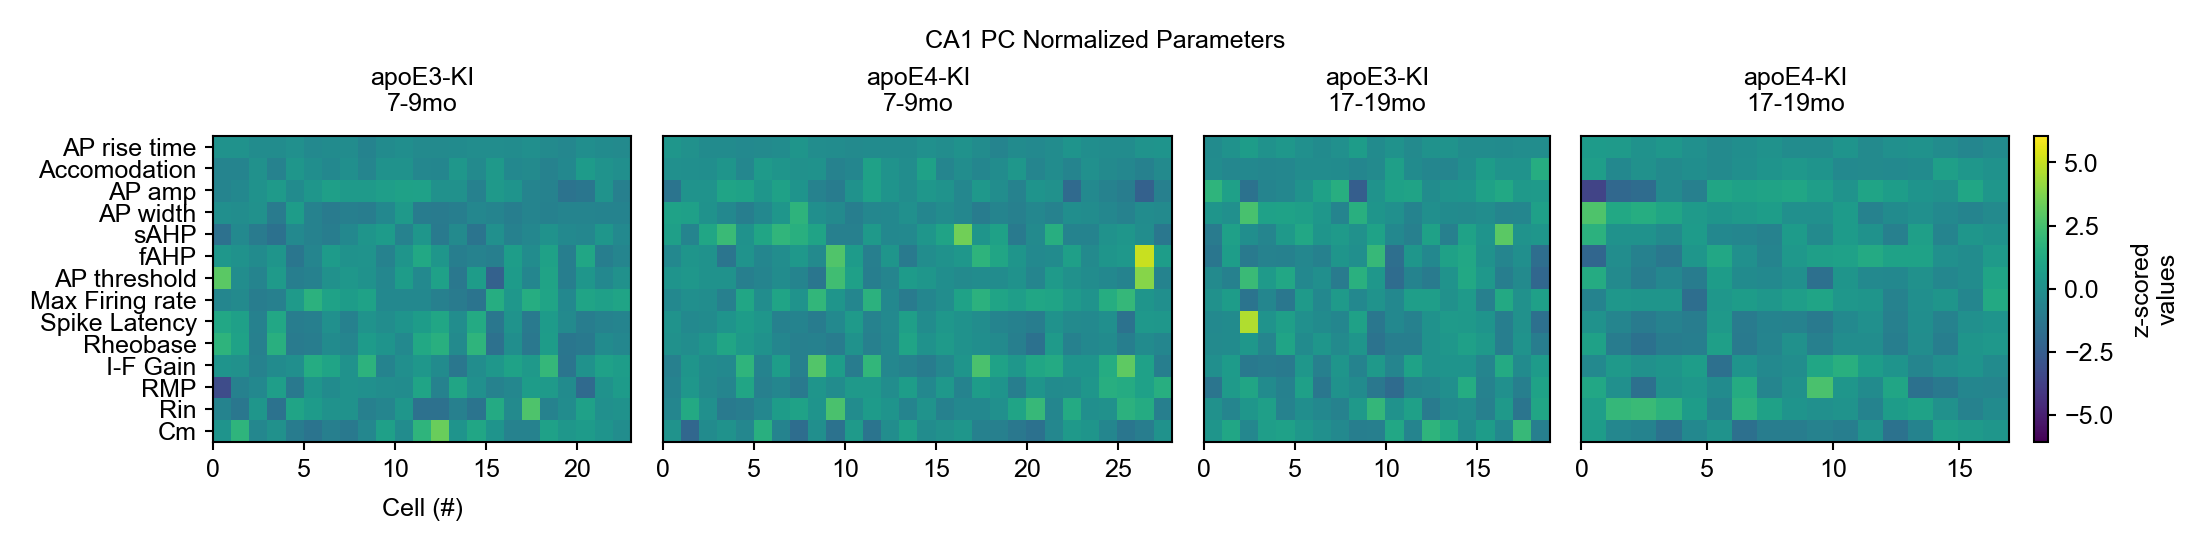

[np.int64(23), np.int64(28), np.int64(19), np.int64(17)]


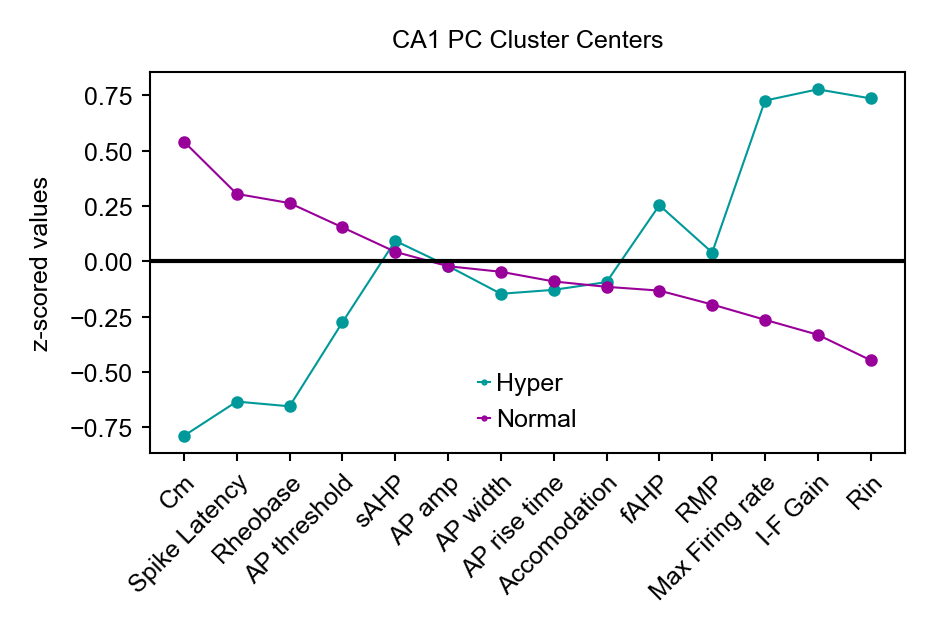

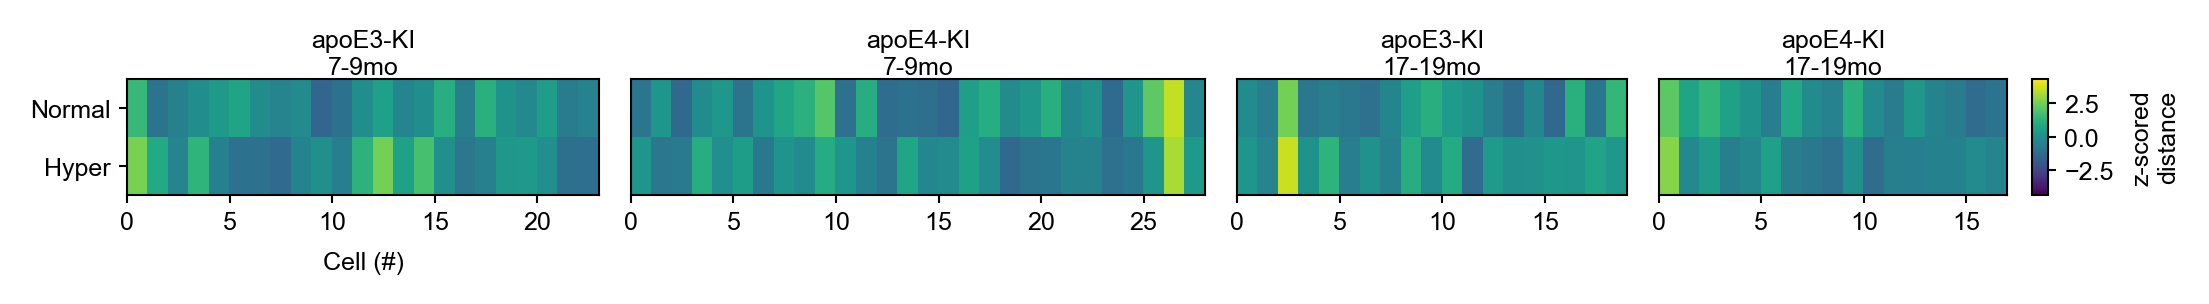

apoE3-KI 7-9mo [0.01568627450980392, 0.2, 1.0, 1]
apoE4-KI 7-9mo [1.0, 0.14901960784313725, 0.0, 1]
apoE3-KI 17-19mo [0.01568627450980392, 0.2, 1.0, 0.8]
apoE4-KI 17-19mo [1.0, 0.14901960784313725, 0.0, 0.8]
[np.float64(-1.756684799205896), np.float64(3.8308454589651566)]


/tmp/ipython-input-1461613550.py:188: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig_sep_scatter.subplots_adjust(wspace=0.3, hspace=0.3)
/tmp/ipython-input-1461613550.py:191: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipython-input-1461613550.py:233: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(ax=ax,data=sns_df,palette=colors_sns,scale ='area', label=t, linewidth=1,inner=None)


sns_dict {'apoE3-KI 7-9mo': [np.float64(-1.024459642974451), np.float64(-3.3809395806213747), np.float64(-0.2845187827929268), np.float64(-1.9684425051759944), np.float64(1.6439772868911464), np.float64(3.452618819730189), np.float64(2.0484594464423607), np.float64(2.515680262643876), np.float64(0.4693642582430426), np.float64(-3.623222880608279), np.float64(-1.123948555381661), np.float64(-1.8341880086474163), np.float64(-2.0952281250182043), np.float64(-1.6115639185302952), np.float64(-2.497419803769845), np.float64(1.6858221287663482), np.float64(0.6698918104817514), np.float64(2.8407885783560065), np.float64(-0.2480287248717583), np.float64(-0.958249815502737), np.float64(0.868940912603759), np.float64(1.139191221667486), np.float64(1.887903985883654)], 'apoE4-KI 7-9mo': [np.float64(-2.380068478193645), np.float64(2.2389133331481483), np.float64(-1.7075160822950162), np.float64(-1.807989006323831), np.float64(0.585419308868915), np.float64(-2.9070809071813692), np.float64(1.9970427

/tmp/ipython-input-1461613550.py:322: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
100%|██████████| 1000/1000 [00:07<00:00, 126.24it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


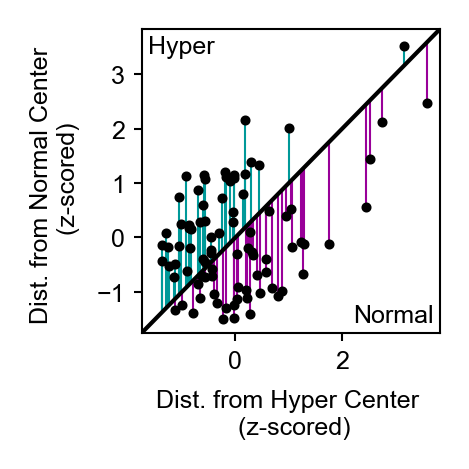

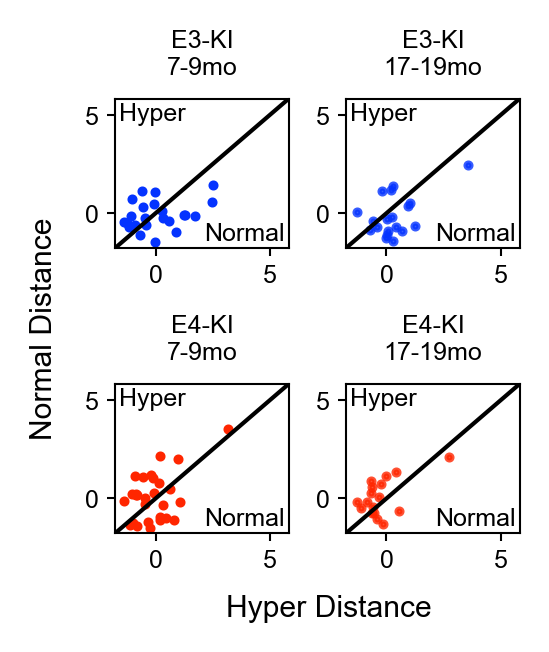

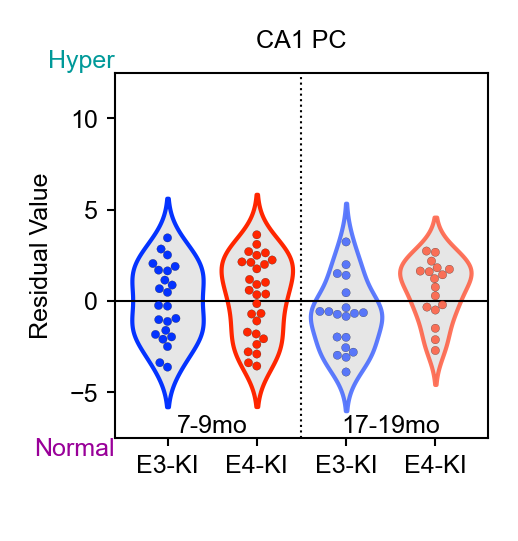

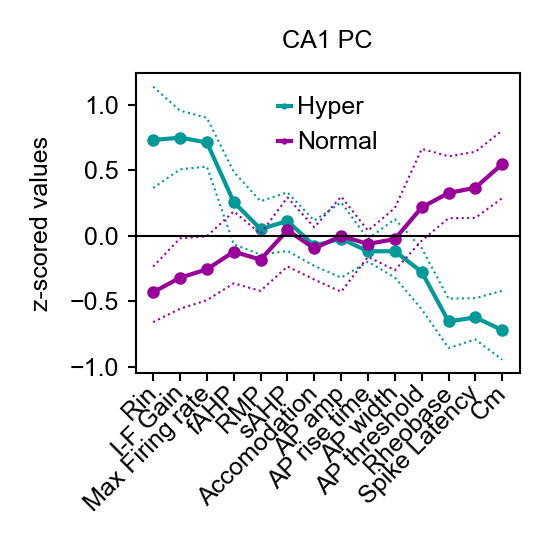

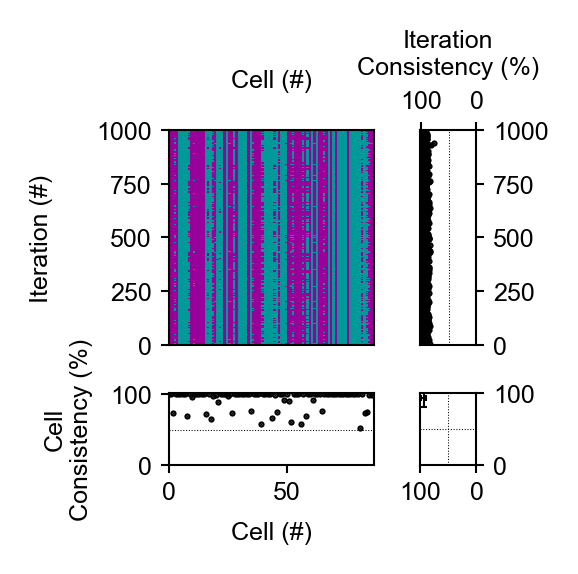

100%|██████████| 1000/1000 [00:09<00:00, 102.52it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 450x450 with 0 Axes>

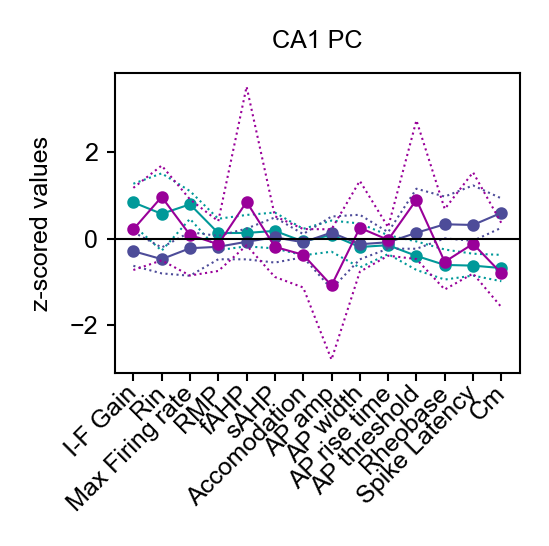

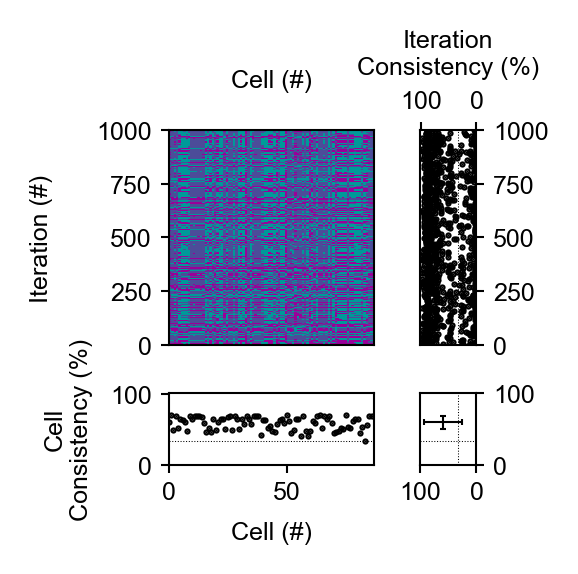

CA1_main_parameters_Clean
  adding: CA1_main_parameters_Clean/ (stored 0%)
  adding: CA1_main_parameters_Clean/CrossVal_Data k=2 Labeling.svg (deflated 87%)
  adding: CA1_main_parameters_Clean/GenoType_dist_Separate.svg (deflated 87%)
  adding: CA1_main_parameters_Clean/fig_violin_residuals.svg (deflated 77%)
  adding: CA1_main_parameters_Clean/CrossVal_Data k=2 Centers.svg (deflated 83%)
  adding: CA1_main_parameters_Clean/GenoType_dist.svg (deflated 85%)
  adding: CA1_main_parameters_Clean/CrossVal_Data k=3 Centers.svg (deflated 83%)
  adding: CA1_main_parameters_Clean/2W_results Age-Geno.csv (deflated 42%)
  adding: CA1_main_parameters_Clean/CrossVal_Data k=3 Labeling.svg (deflated 82%)
  adding: CA1_main_parameters_Clean/fig_distances_split.svg (deflated 88%)
  adding: CA1_main_parameters_Clean/pairwise Age-Genotype.csv (deflated 54%)
  adding: CA1_main_parameters_Clean/Scores.csv (deflated 72%)
  adding: CA1_main_parameters_Clean/Normalized_Vals_split.svg (deflated 91%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

random_state 43
[1.37479286]


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<Figure size 450x450 with 0 Axes>

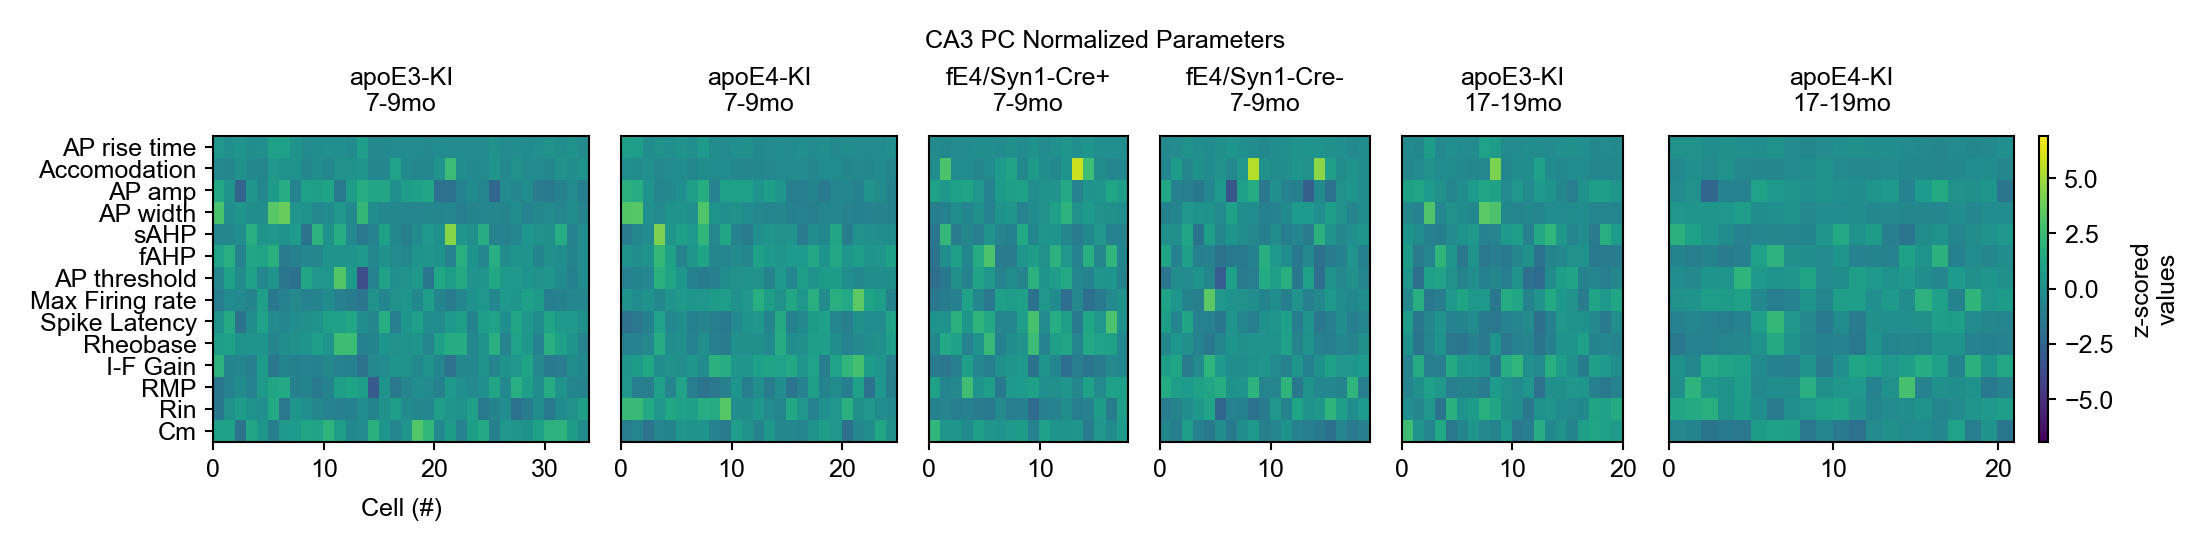

[np.int64(34), np.int64(25), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]


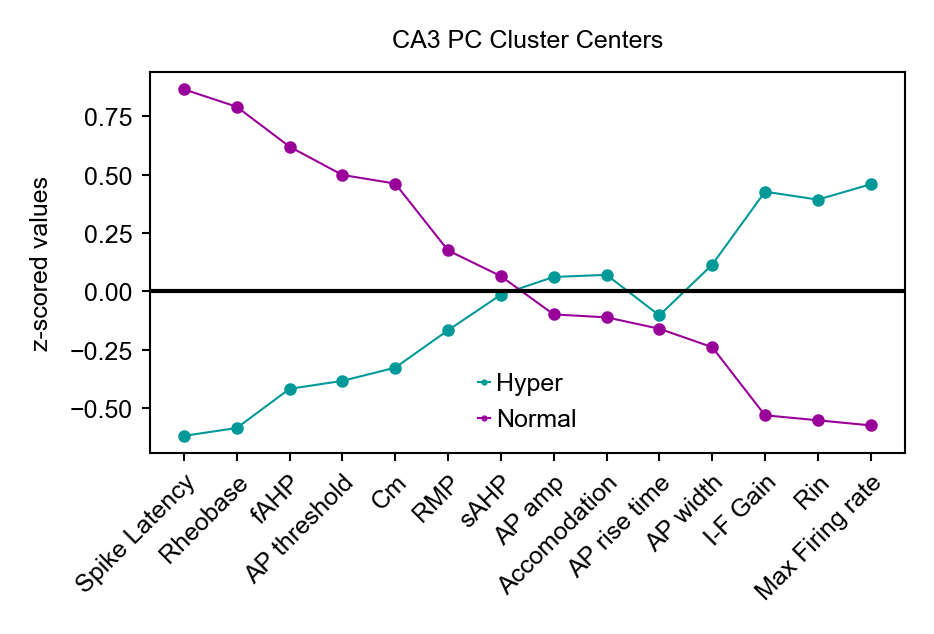

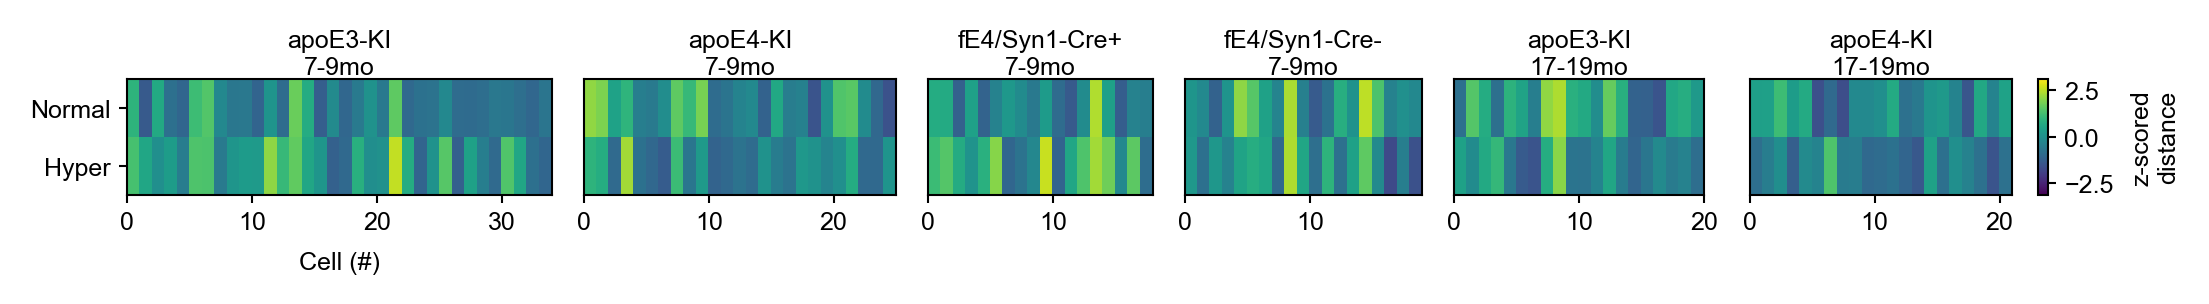

apoE3-KI 7-9mo [0.01568627450980392, 0.2, 1.0, 1]
apoE4-KI 7-9mo [1.0, 0.14901960784313725, 0.0, 1]
fE4/Syn1-Cre+ 7-9mo [0.403921568627451, 0.13725490196078433, 0.00784313725490196, 1]
fE4/Syn1-Cre- 7-9mo [0.403921568627451, 0.13725490196078433, 0.00784313725490196, 0.8]
apoE3-KI 17-19mo [0.01568627450980392, 0.2, 1.0, 0.8]
apoE4-KI 17-19mo [1.0, 0.14901960784313725, 0.0, 0.8]
[np.float64(-1.923398701255301), np.float64(2.8056167951698736)]


/tmp/ipython-input-1461613550.py:188: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig_sep_scatter.subplots_adjust(wspace=0.3, hspace=0.3)
/tmp/ipython-input-1461613550.py:191: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipython-input-1461613550.py:233: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(ax=ax,data=sns_df,palette=colors_sns,scale ='area', label=t, linewidth=1,inner=None)


sns_dict {'apoE3-KI 7-9mo': [np.float64(-0.5370100700930911), np.float64(-3.829358792817929), np.float64(0.9543232341295624), np.float64(-2.083084782802972), np.float64(-1.2451767595249073), np.float64(-0.34432588580396395), np.float64(-0.05369897770797519), np.float64(0.6912124530658721), np.float64(-1.3809368290591604), np.float64(-1.5890849284691537), np.float64(-2.6785332247337426), np.float64(-2.435038202630542), np.float64(-3.296962176782303), np.float64(-0.041817784833264815), np.float64(0.14408324631390823), np.float64(-2.8533804436369214), np.float64(2.343487655166835), np.float64(0.023537143699851465), np.float64(-2.2614235076800737), np.float64(0.13417376855587712), np.float64(-1.1089489496971092), np.float64(-1.063803980933166), np.float64(-3.0846472729269534), np.float64(0.9715683817405241), np.float64(-1.505759959860361), np.float64(-2.3567182925842545), np.float64(0.8872465637607301), np.float64(-2.5857056207090166), np.float64(-0.830755701969973), np.float64(0.885854837

/tmp/ipython-input-1461613550.py:322: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
100%|██████████| 1000/1000 [00:08<00:00, 116.38it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


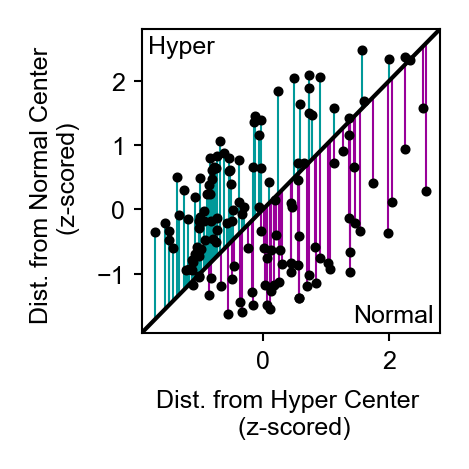

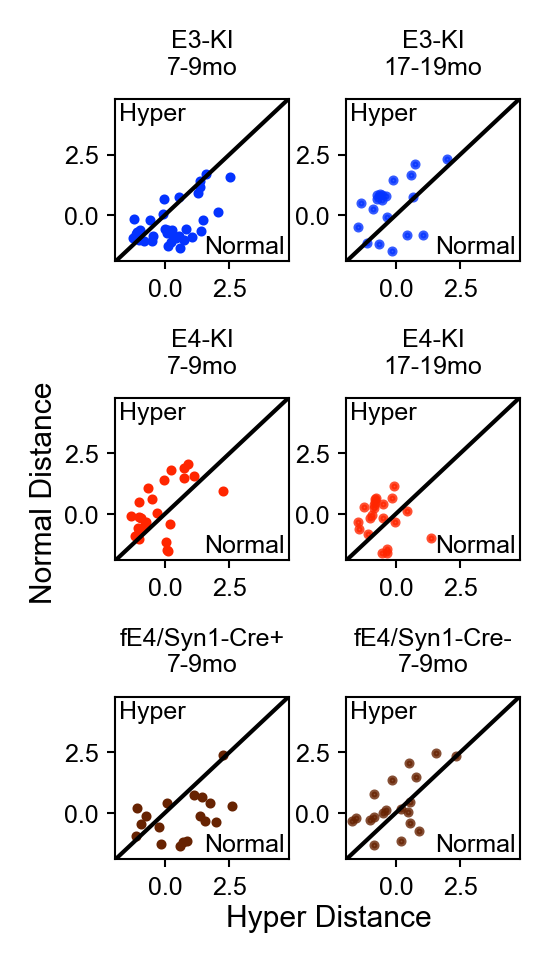

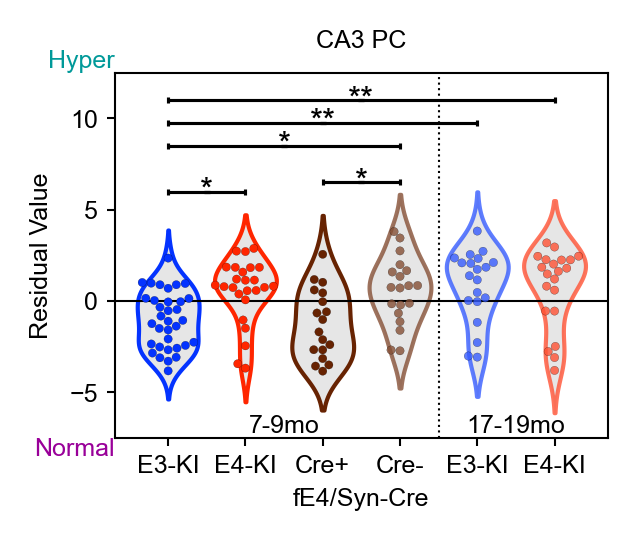

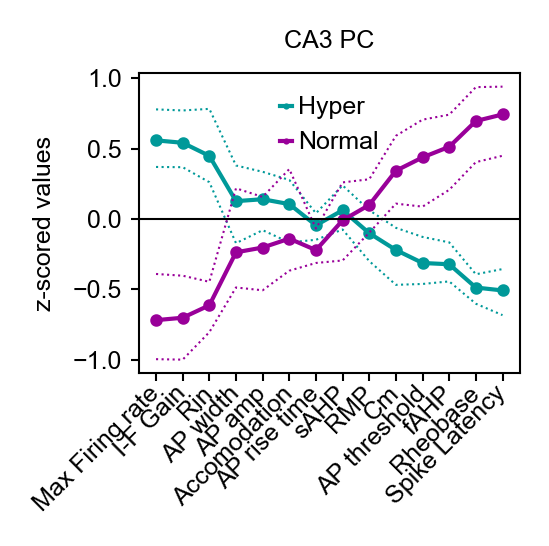

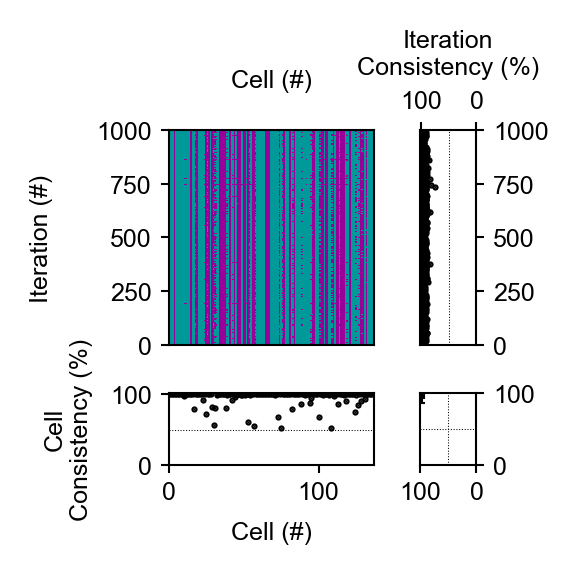

100%|██████████| 1000/1000 [00:12<00:00, 79.03it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 450x450 with 0 Axes>

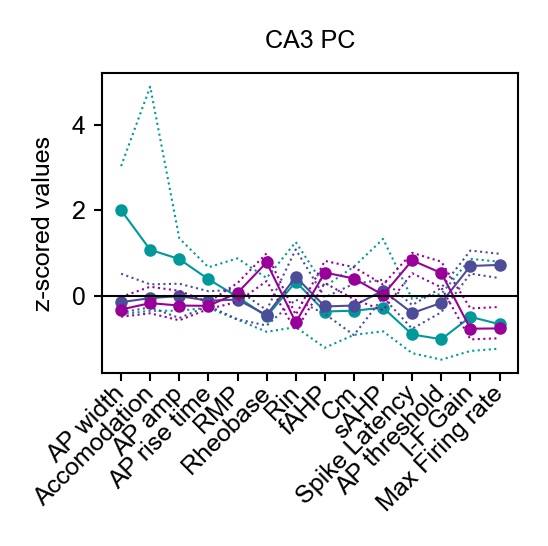

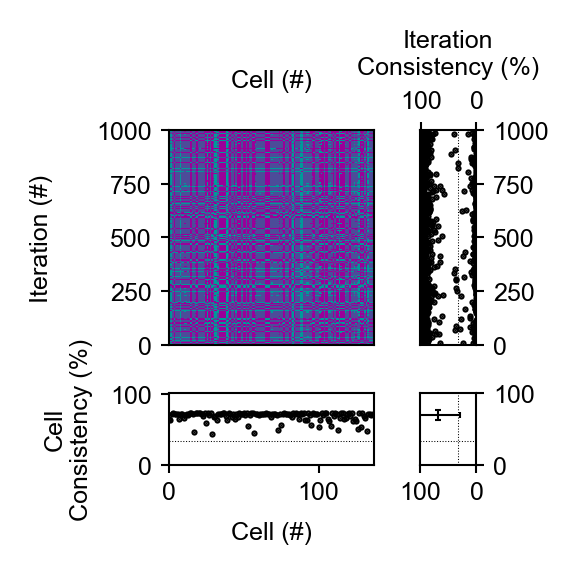

CA3_parameters_for_PCA_Clean
  adding: CA3_parameters_for_PCA_Clean/ (stored 0%)
  adding: CA3_parameters_for_PCA_Clean/CrossVal_Data k=2 Labeling.svg (deflated 87%)
  adding: CA3_parameters_for_PCA_Clean/GenoType_dist_Separate.svg (deflated 88%)
  adding: CA3_parameters_for_PCA_Clean/fig_violin_residuals.svg (deflated 79%)
  adding: CA3_parameters_for_PCA_Clean/CrossVal_Data k=2 Centers.svg (deflated 83%)
  adding: CA3_parameters_for_PCA_Clean/GenoType_dist.svg (deflated 86%)
  adding: CA3_parameters_for_PCA_Clean/CrossVal_Data k=3 Centers.svg (deflated 83%)
  adding: CA3_parameters_for_PCA_Clean/2W_results Age-Geno.csv (deflated 38%)
  adding: CA3_parameters_for_PCA_Clean/CrossVal_Data k=3 Labeling.svg (deflated 83%)
  adding: CA3_parameters_for_PCA_Clean/fig_distances_split.svg (deflated 88%)
  adding: CA3_parameters_for_PCA_Clean/pairwise Age-Genotype.csv (deflated 64%)
  adding: CA3_parameters_for_PCA_Clean/Scores.csv (deflated 73%)
  adding: CA3_parameters_for_PCA_Clean/Normalize

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

random_state 44
[0.78680439]


<Figure size 450x450 with 0 Axes>

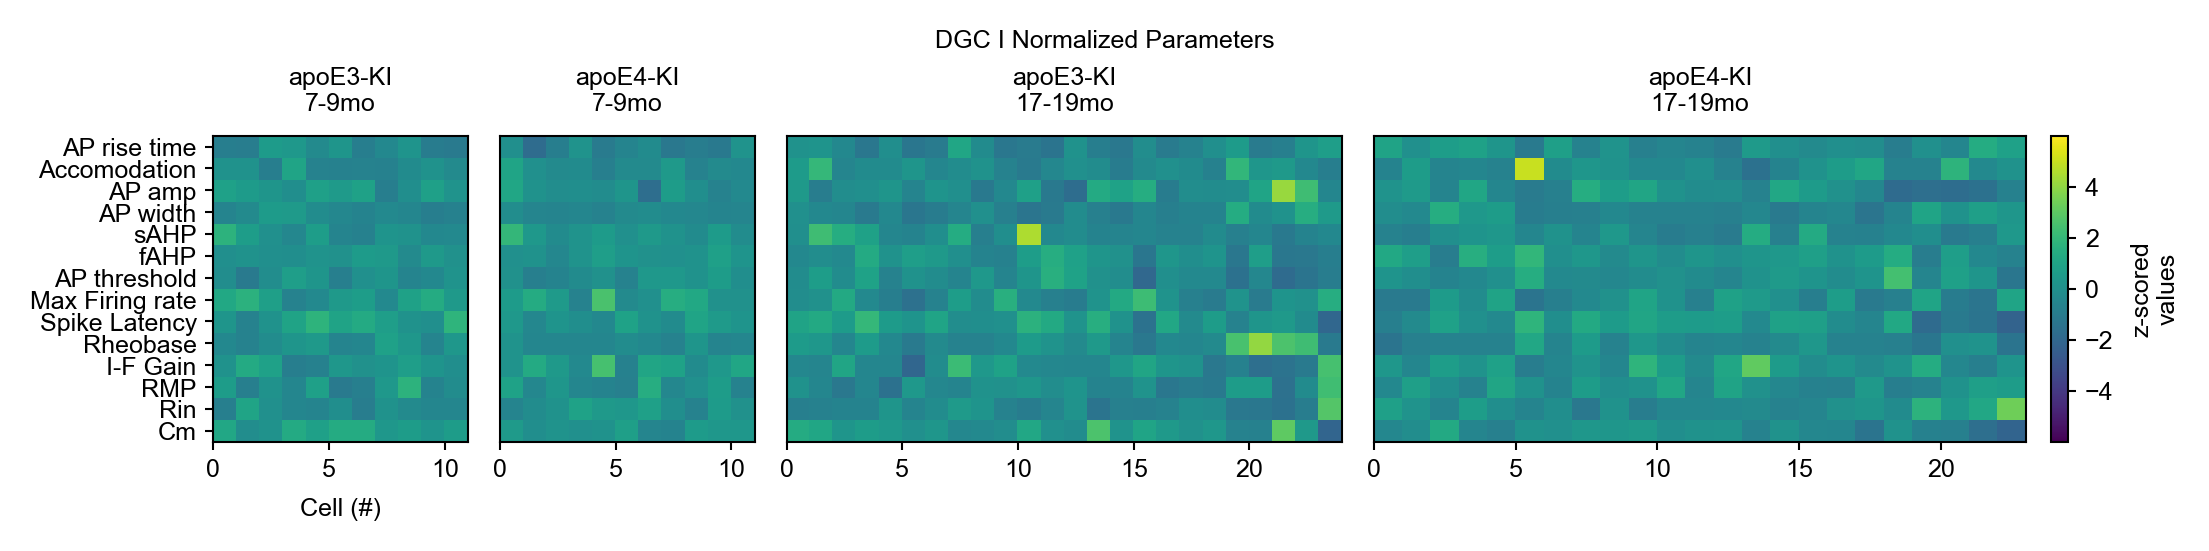

[np.int64(11), np.int64(11), np.int64(24), np.int64(23)]


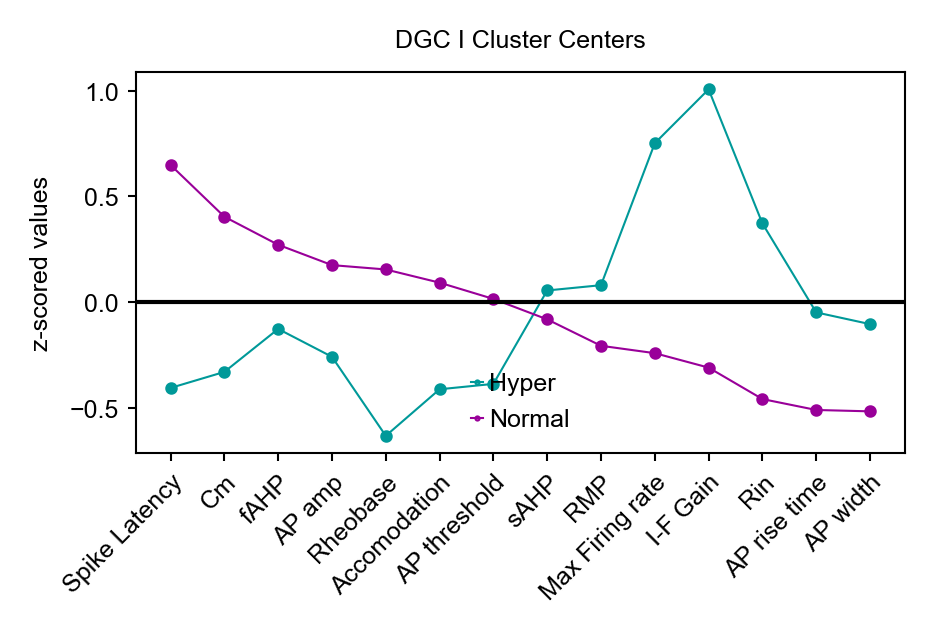

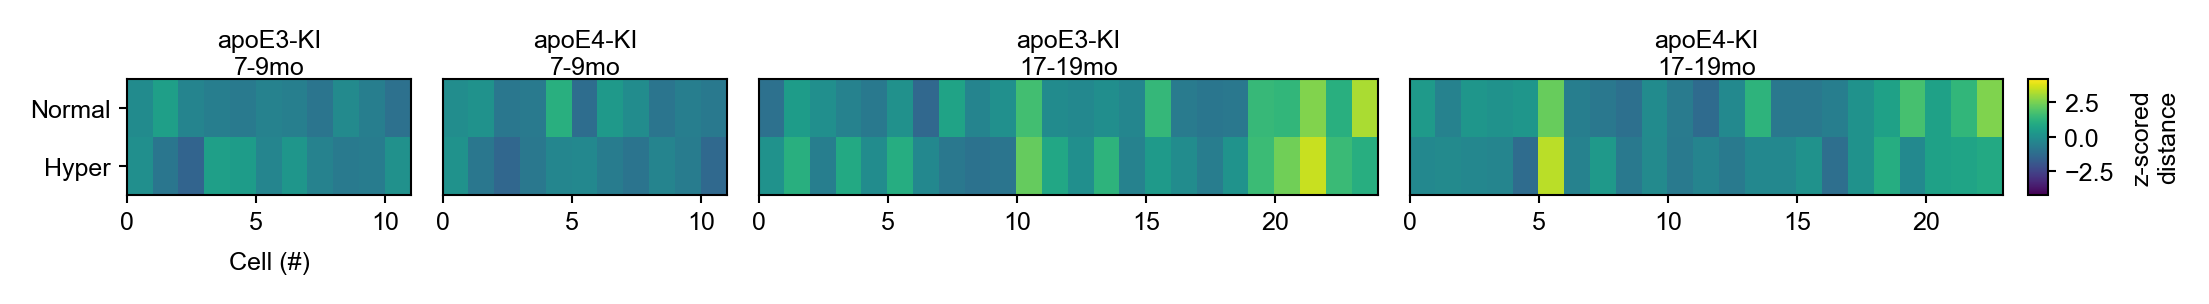

apoE3-KI 7-9mo [0.01568627450980392, 0.2, 1.0, 1]
apoE4-KI 7-9mo [1.0, 0.14901960784313725, 0.0, 1]
apoE3-KI 17-19mo [0.01568627450980392, 0.2, 1.0, 0.8]
apoE4-KI 17-19mo [1.0, 0.14901960784313725, 0.0, 0.8]
[np.float64(-1.75394422733727), np.float64(3.727129885794412)]


/tmp/ipython-input-1461613550.py:188: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig_sep_scatter.subplots_adjust(wspace=0.3, hspace=0.3)
/tmp/ipython-input-1461613550.py:191: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipython-input-1461613550.py:233: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(ax=ax,data=sns_df,palette=colors_sns,scale ='area', label=t, linewidth=1,inner=None)


sns_dict {'apoE3-KI 7-9mo': [np.float64(-0.20972852850383716), np.float64(3.3126144739684236), np.float64(3.6116871147519154), np.float64(-2.5320430077382645), np.float64(-2.7132614688497654), np.float64(-0.3942629996341635), np.float64(-1.9074245134540728), np.float64(-1.3372450464341736), np.float64(1.3965386431912332), np.float64(0.10282203116783892), np.float64(-3.2600370750947327)], 'apoE4-KI 7-9mo': [np.float64(-0.36141368830968823), np.float64(2.35308479492347), np.float64(1.7817880218101472), np.float64(-0.03217346202106938), np.float64(2.839969419276224), np.float64(-3.0734778514490015), np.float64(2.4413807608877005), np.float64(2.1165808091312472), np.float64(-1.7295869361148033), np.float64(0.08646153933799411), np.float64(1.8162358505489955)], 'apoE3-KI 17-19mo': [np.float64(-3.3274385529179513), np.float64(-0.9619290813457889), np.float64(1.4121252534708726), np.float64(-2.579457734989454), np.float64(-1.8004567605674588), np.float64(-1.580938232955545), np.float64(-3.934

/tmp/ipython-input-1461613550.py:322: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
100%|██████████| 1000/1000 [00:07<00:00, 128.10it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


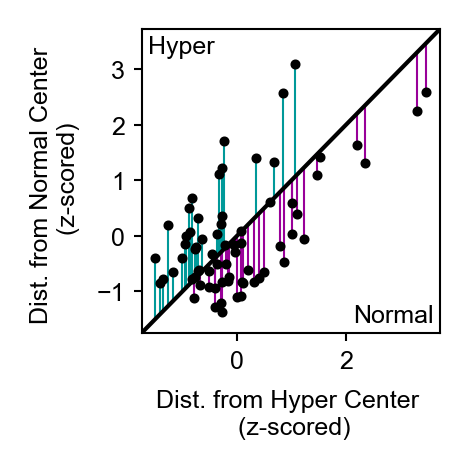

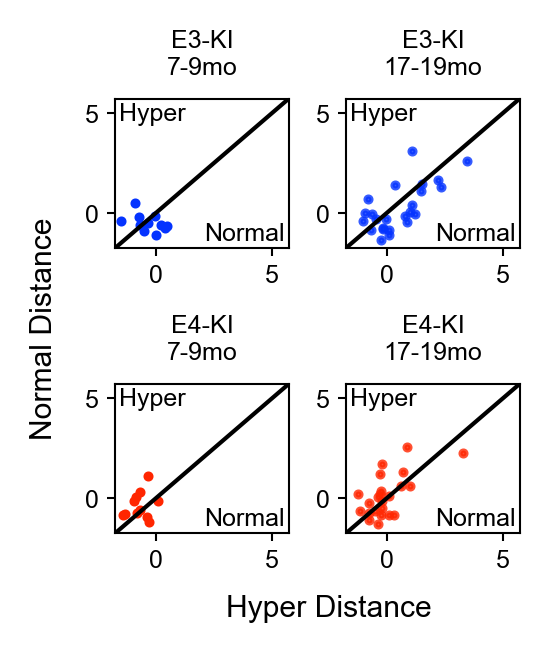

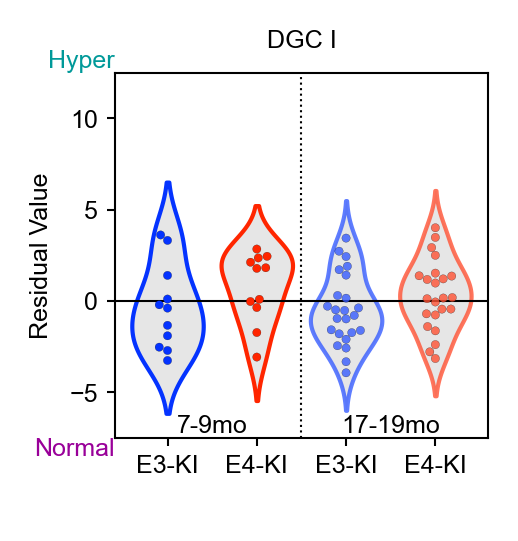

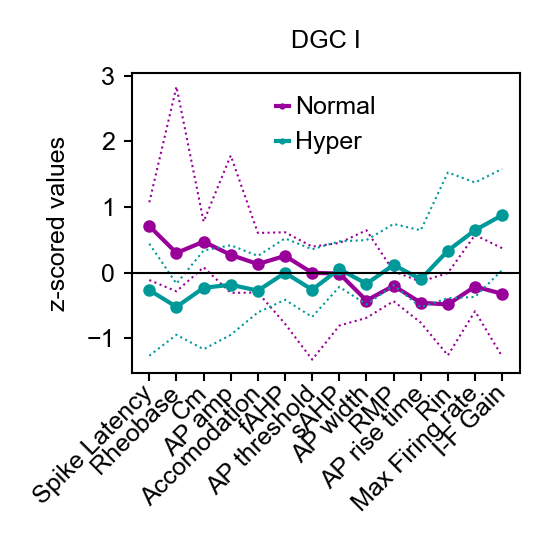

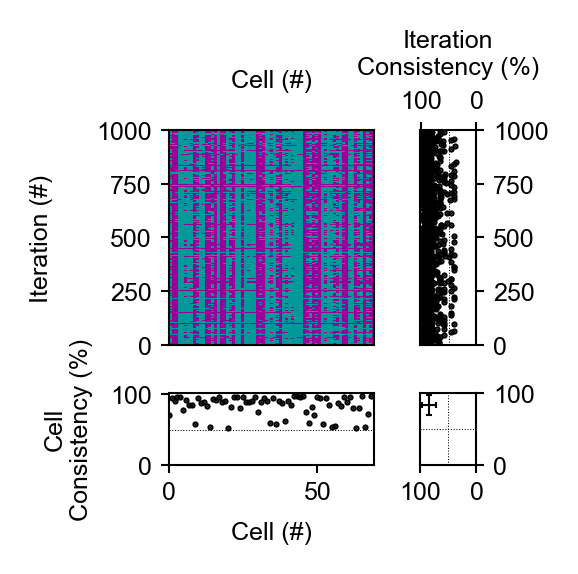

100%|██████████| 1000/1000 [00:10<00:00, 97.63it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 450x450 with 0 Axes>

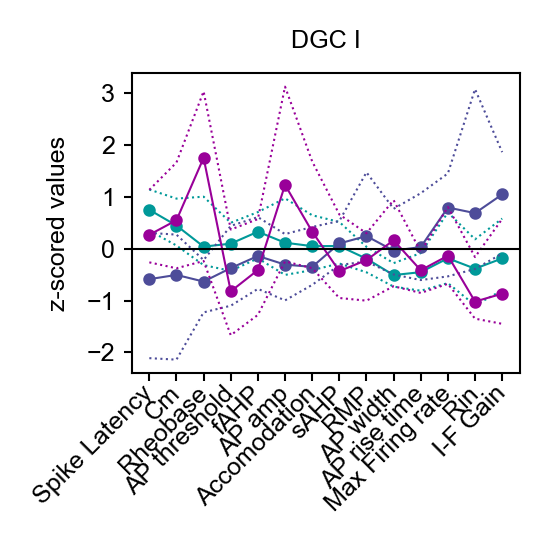

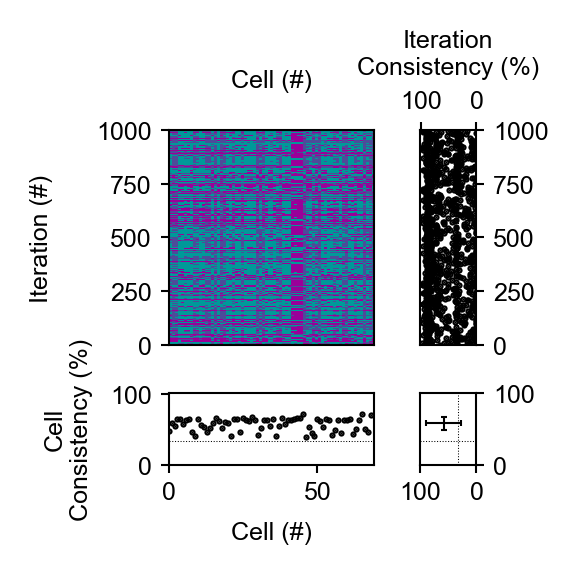

DG_Type_I_GC_main_parameters_Clean
  adding: DG_Type_I_GC_main_parameters_Clean/ (stored 0%)
  adding: DG_Type_I_GC_main_parameters_Clean/CrossVal_Data k=2 Labeling.svg (deflated 86%)
  adding: DG_Type_I_GC_main_parameters_Clean/GenoType_dist_Separate.svg (deflated 87%)
  adding: DG_Type_I_GC_main_parameters_Clean/fig_violin_residuals.svg (deflated 76%)
  adding: DG_Type_I_GC_main_parameters_Clean/CrossVal_Data k=2 Centers.svg (deflated 82%)
  adding: DG_Type_I_GC_main_parameters_Clean/GenoType_dist.svg (deflated 85%)
  adding: DG_Type_I_GC_main_parameters_Clean/CrossVal_Data k=3 Centers.svg (deflated 83%)
  adding: DG_Type_I_GC_main_parameters_Clean/2W_results Age-Geno.csv (deflated 43%)
  adding: DG_Type_I_GC_main_parameters_Clean/CrossVal_Data k=3 Labeling.svg (deflated 84%)
  adding: DG_Type_I_GC_main_parameters_Clean/fig_distances_split.svg (deflated 87%)
  adding: DG_Type_I_GC_main_parameters_Clean/pairwise Age-Genotype.csv (deflated 53%)
  adding: DG_Type_I_GC_main_parameters_Cl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

random_state 43
[-1.15966693]
random_state 44
[1.09325668]


<Figure size 450x450 with 0 Axes>

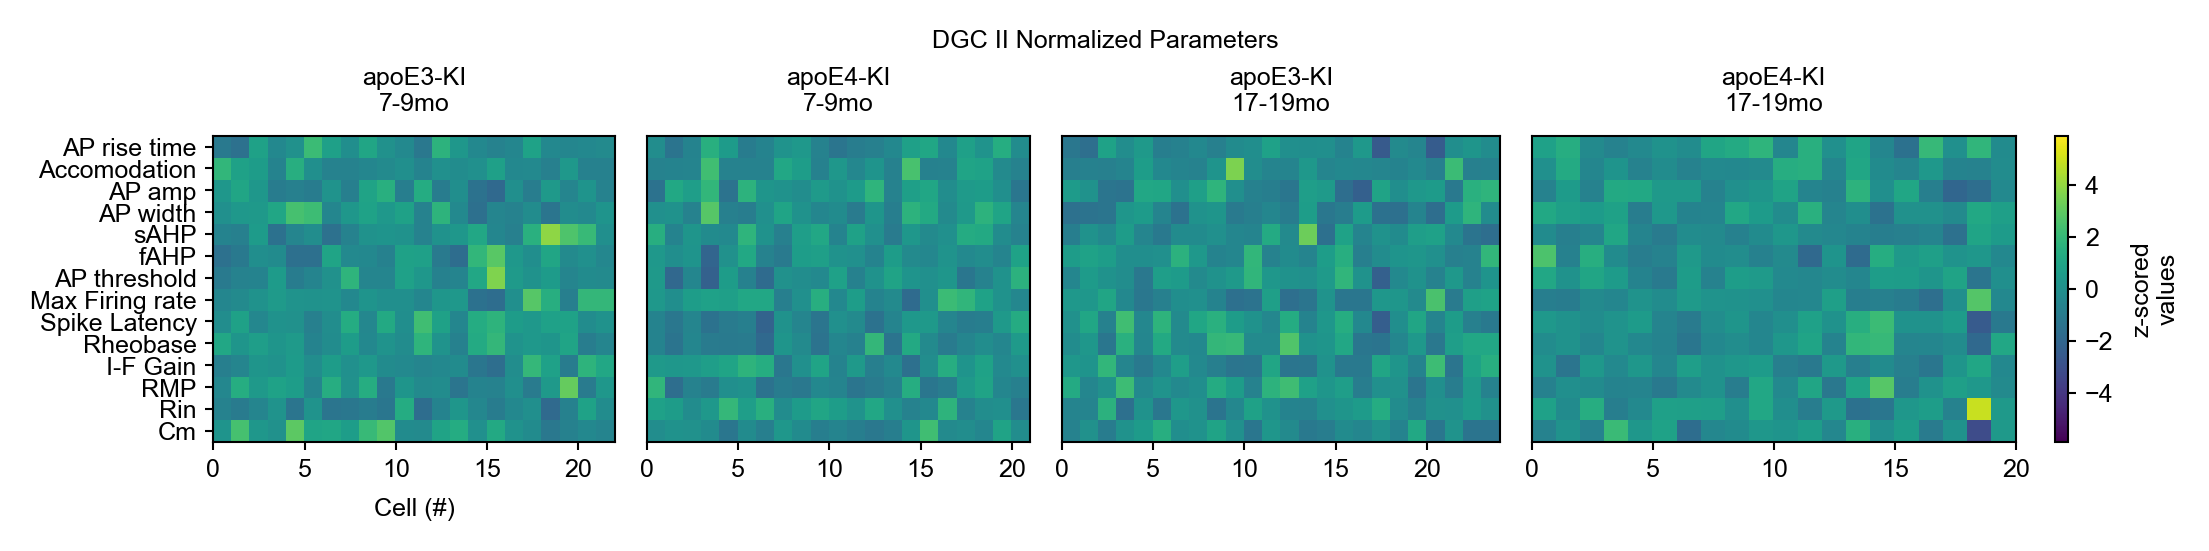

[np.int64(22), np.int64(21), np.int64(24), np.int64(20)]


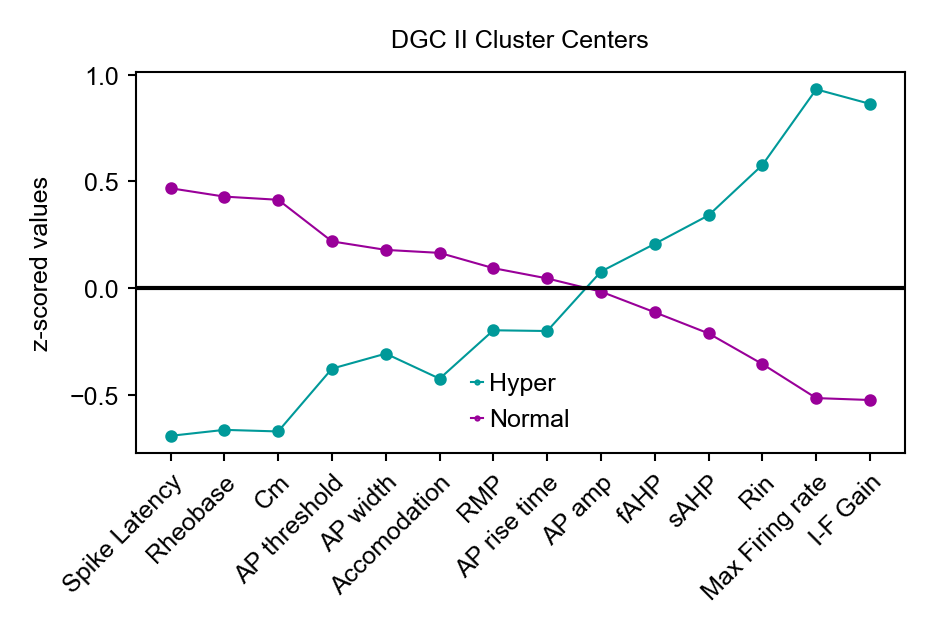

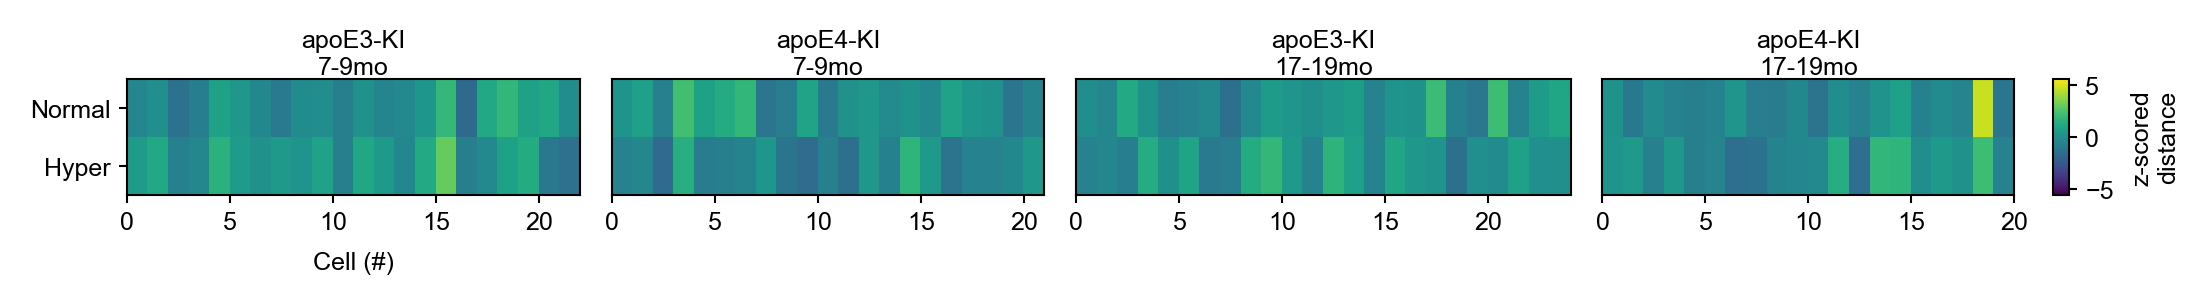

apoE3-KI 7-9mo [0.01568627450980392, 0.2, 1.0, 1]
apoE4-KI 7-9mo [1.0, 0.14901960784313725, 0.0, 1]
apoE3-KI 17-19mo [0.01568627450980392, 0.2, 1.0, 0.8]
apoE4-KI 17-19mo [1.0, 0.14901960784313725, 0.0, 0.8]
[np.float64(-2.107921034612226), np.float64(4.965418002348627)]


/tmp/ipython-input-1461613550.py:188: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig_sep_scatter.subplots_adjust(wspace=0.3, hspace=0.3)
/tmp/ipython-input-1461613550.py:191: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipython-input-1461613550.py:233: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(ax=ax,data=sns_df,palette=colors_sns,scale ='area', label=t, linewidth=1,inner=None)


sns_dict {'apoE3-KI 7-9mo': [np.float64(-1.7020446519156764), np.float64(-1.8065527507460462), np.float64(-1.3930000872812398), np.float64(-0.9500615100461971), np.float64(-1.1135181353786998), np.float64(-0.31987762050026897), np.float64(-0.738766218881544), np.float64(-2.7853309239126034), np.float64(-0.7989197379985848), np.float64(-1.5912223865411055), np.float64(0.0019398455926595004), np.float64(-1.624159152628644), np.float64(-1.6098523695234994), np.float64(0.18993694892939875), np.float64(-1.3140075590545237), np.float64(-1.2187337543594217), np.float64(-2.667898898315202), np.float64(2.0362049950074455), np.float64(0.9701749378486573), np.float64(-0.6981257644156337), np.float64(3.766546918848433), np.float64(3.1619578131862887)], 'apoE4-KI 7-9mo': [np.float64(1.5086027265968507), np.float64(1.7638614912022332), np.float64(3.223697088911), np.float64(0.64732008406944), np.float64(3.0442262620061995), np.float64(3.280466434581114), np.float64(3.3305147534395823), np.float64(-3

/tmp/ipython-input-1461613550.py:322: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
100%|██████████| 1000/1000 [00:09<00:00, 101.80it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


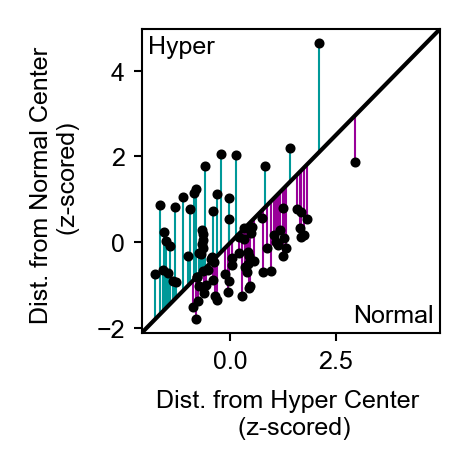

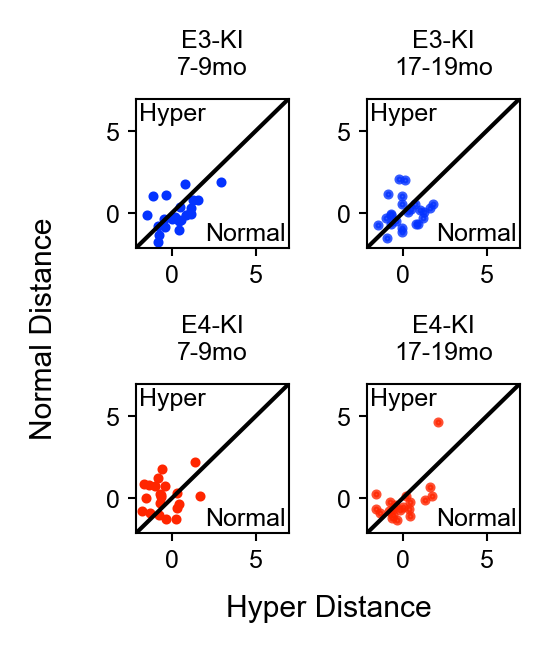

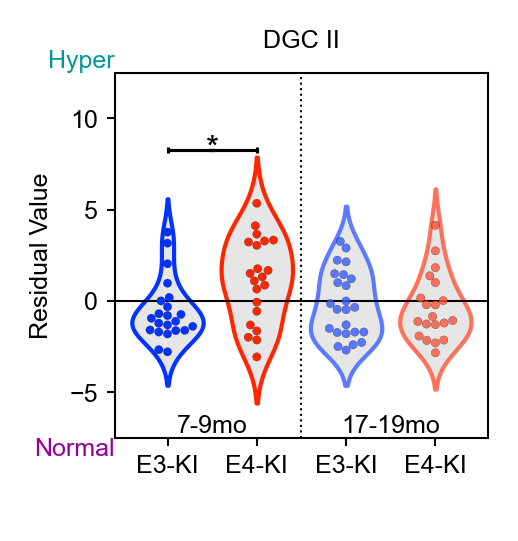

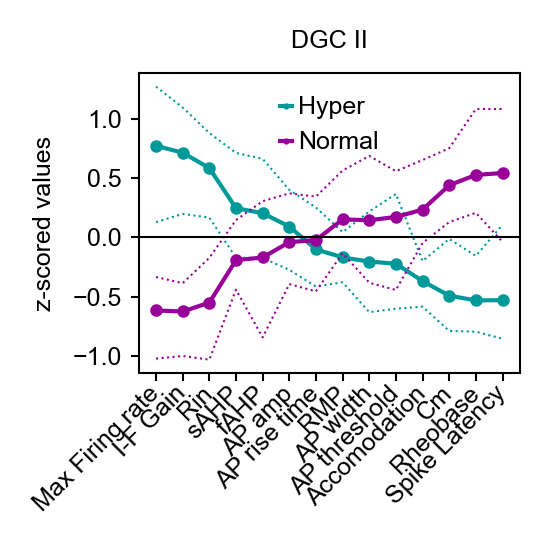

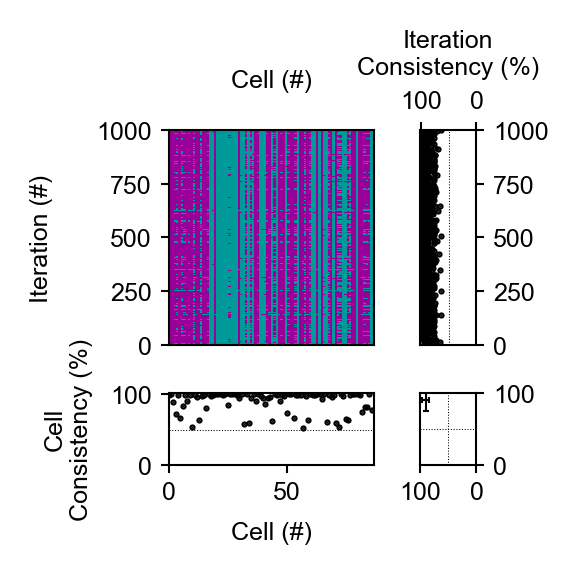

100%|██████████| 1000/1000 [00:12<00:00, 80.34it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 450x450 with 0 Axes>

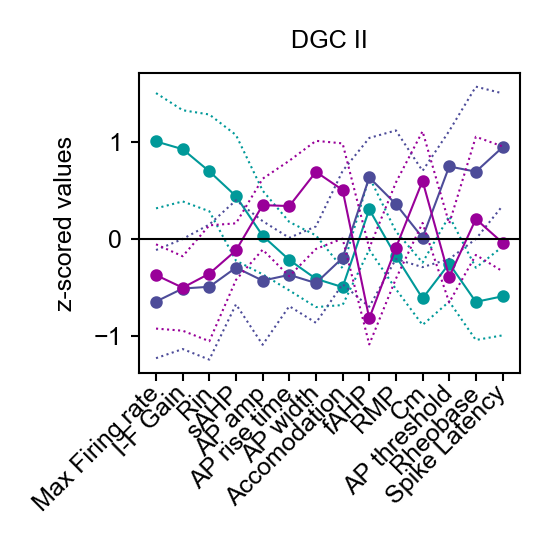

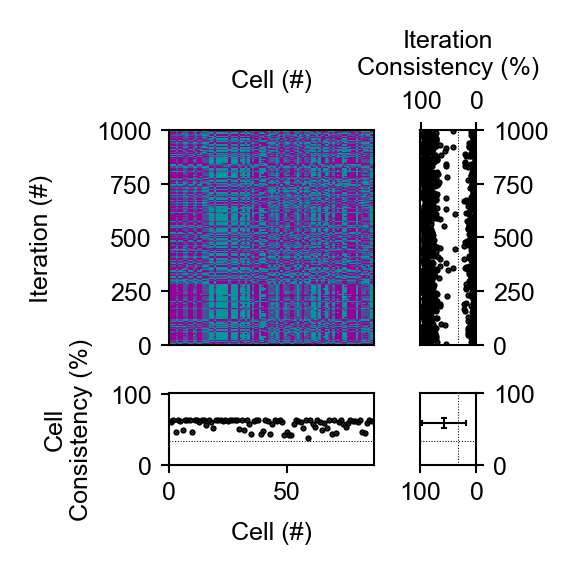

DG_Type_II_GC_main_parameters_Clean
  adding: DG_Type_II_GC_main_parameters_Clean/ (stored 0%)
  adding: DG_Type_II_GC_main_parameters_Clean/CrossVal_Data k=2 Labeling.svg (deflated 86%)
  adding: DG_Type_II_GC_main_parameters_Clean/GenoType_dist_Separate.svg (deflated 87%)
  adding: DG_Type_II_GC_main_parameters_Clean/fig_violin_residuals.svg (deflated 77%)
  adding: DG_Type_II_GC_main_parameters_Clean/CrossVal_Data k=2 Centers.svg (deflated 83%)
  adding: DG_Type_II_GC_main_parameters_Clean/GenoType_dist.svg (deflated 85%)
  adding: DG_Type_II_GC_main_parameters_Clean/CrossVal_Data k=3 Centers.svg (deflated 83%)
  adding: DG_Type_II_GC_main_parameters_Clean/2W_results Age-Geno.csv (deflated 43%)
  adding: DG_Type_II_GC_main_parameters_Clean/CrossVal_Data k=3 Labeling.svg (deflated 83%)
  adding: DG_Type_II_GC_main_parameters_Clean/fig_distances_split.svg (deflated 88%)
  adding: DG_Type_II_GC_main_parameters_Clean/pairwise Age-Genotype.csv (deflated 53%)
  adding: DG_Type_II_GC_main_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 450x450 with 0 Axes>

In [25]:
### Cycle throught Data tables, cluster, and plot. ###



multipack={}

fig_opt = {'dpi': 300, 'format':'svg','bbox_inches':None}


for f in file_list: #  [f for f in file_list if 'CA3' in f]:#
    my_df_dict, xl_to_analyze = read_data_file(f,dir='./'+git_rep+'/Cleaned_DataSets/')
    folder = xl_to_analyze.split('.')[0].replace(' ','_')
    try: os.makedirs(folder)
    except: None
    full_df = dict_to_df(my_df_dict,AP_cut=60)
    labeling = ['cell','Cell','type','extra']
    numericals, data_for_fit, full_df_no_null = clean_data(labeling, full_df)
    type_num, num_t, uniq_types,type_list = get_types(full_df_no_null)
    packaged = cluster_full(data_for_fit,xl_to_analyze,numericals)
    packaged['type_num'] = type_num
    if 'CA1' in f: packaged['cell_type'] ='CA1 PC'
    if 'CA3' in f: packaged['cell_type'] ='CA3 PC'
    if 'II' in f: packaged['cell_type'] ='DGC II'
    if ' I ' in f: packaged['cell_type'] ='DGC I'
    df_for_34_2W_anova, tukey_data = do_stats(type_list,packaged['score'])
    plot_summary(num_t,numericals,type_list,uniq_types,packaged,df_for_34_2W_anova,tukey_data,folder,fig_opt =fig_opt)
    k2_cval = cross_val(data_for_fit,numericals,packaged['new_cent_order'],folder,k=2,num_iter = 1000,SubSampleFrac = .8,
              cell_type=packaged['cell_type'],fig_opt =fig_opt,ds_iter=1)
    k3_cval = cross_val(data_for_fit,numericals,packaged['new_cent_order'],folder,k=3,num_iter = 1000,SubSampleFrac = .8,
              cell_type=packaged['cell_type'],fig_opt =fig_opt,ds_iter=1)
    packaged['k2_cval'] = k2_cval
    packaged['k3_cval'] = k3_cval
    multipack[packaged['cell_type']] = packaged
    save_dl(folder)

In [26]:
########### Write K-Means Values ################
all_dfs = dict()
for celltype, data in multipack.items():
    # print(celltype)
    # print(data.keys())
    # print(data['features'])
    # print(data['k2_cval'])

    # Create dictionary with features column
    df_dict = {'features': data['features']}

    # Add a column for each cluster center
    for i in range(data['centers'].shape[1]):
        df_dict[f'full_centroid_K{i}'] = data['centers'][:, i]

    means = data['k2_cval']['mean_center']
    for i in range(means.shape[1]):
        df_dict[f'mean_centroid_K{i}'] = means[:, i]

    confidence = data['k2_cval']['confidence']
    for i in range(confidence.shape[2]):  # Iterate over clusters (last dimension)
        df_dict[f'confidence_low_K{i}'] = confidence[0, :, i]  # Low bound
        df_dict[f'confidence_high_K{i}'] = confidence[1, :, i]  # High bound

    feat_df = pd.DataFrame(df_dict)
    feat_df = feat_df.sort_values('full_centroid_K0', ascending=False)
    feat_df = feat_df.rename(columns=lambda x: x.replace('K0', 'Hyper').replace('K1', 'Normal'))
    all_dfs[celltype] = feat_df


# Write to multi-tabbed Excel file
with pd.ExcelWriter('kmeans_results.xlsx', engine='openpyxl') as writer:
    for celltype, df in all_dfs.items():
        df.to_excel(writer, sheet_name=celltype, index=False)

print("Excel file 'kmeans_results.xlsx' created successfully!")
colab.files.download('kmeans_results.xlsx')

Excel file 'kmeans_results.xlsx' created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[0 2 4 6 1 3 5 7]


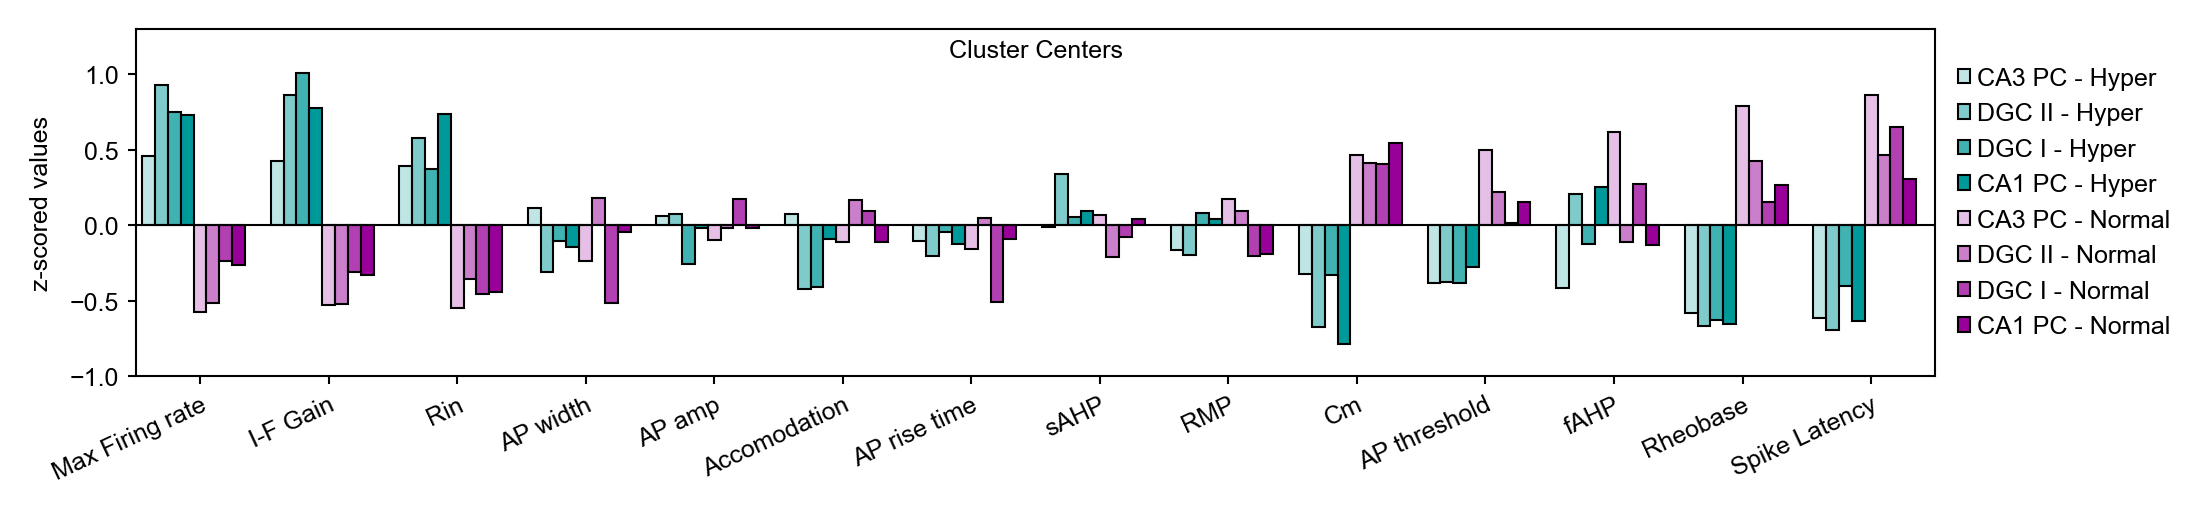

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
############### Combined Centers Plot ####################
FS=6
# set_font_all(FS)
dpi=300
num_types = len(multipack)
fig_combined_centers, ax = plt.subplots(1,1,figsize=np.array([7.25,1.6])*1,dpi=dpi,layout="constrained")
cmap = plt.cm.cool(np.linspace(0,1,2))*np.array([0.6]*3+[1])
dark_cool = mpl.colors.ListedColormap(cmap)
# cent_ord =  multipack['CA3 PC']['new_cent_order']
features =  np.array(multipack['CA3 PC']['features'])

mean_center = multipack['CA3 PC']['k2_cval']['mean_center']
plot_order = np.argsort(np.diff(mean_center,1).T)[0]

keys = multipack.keys()
keys = ['CA3 PC', 'DGC II', 'DGC I', 'CA1 PC' ]
for ci in range(num_types):
    # ci_type = list(multipack.keys())[ci]
    ci_type = keys[ci]

    centers = multipack[ci_type]['centers']

    bar_wid = 1/(num_types*2+2)
    x = np.arange(len(features))

    m_color = cmap[0,:]*[1,1,1,(ci+1)/4]
    m_ys = centers[:,0]
    m_label = ci_type + ' - Hyper'
    m_x =  x + (ci+1)*bar_wid - 0.5
    ax.bar(m_x,m_ys[plot_order],color=m_color,edgecolor='k',width=bar_wid,label=m_label,linewidth=.5)

    l_color = cmap[1,:]*[1,1,1,(ci+1)/4]
    l_ys = centers[:,1]
    l_label = ci_type + ' - Normal'
    l_x =  m_x + (num_types)*bar_wid
    ax.bar(l_x,l_ys[plot_order],color=l_color,edgecolor='k',width=bar_wid,label=l_label,linewidth=.5)

ax.set_xticks(x)
ax.set_ylim(bottom=-1, top=1.3)
ax.set_xlim(-0.5,x[-1]+.5)
ax.set_xticklabels(features[plot_order],rotation=25,ha='right', rotation_mode='anchor')
ax.axhline(0,color='k',linewidth=.5)
# ax.axvline(0,color='k')
ax.set_ylabel('z-scored'+' '+'values')
# ax.title.set_text('Cluster Centers')
ax.text(np.mean(ax.get_xlim()),ax.get_ylim()[-1]*.95,'Cluster Centers',ha='center',va='top')
handles, bar_labels = plt.gca().get_legend_handles_labels()
order = np.arange(8)
order = np.append(np.arange(num_types)*2,np.arange(num_types)*2+1)
print(order)
ax.legend([handles[i] for i in order],[bar_labels[i] for i in order],ncol=1,loc='center left',frameon=False,bbox_to_anchor=(1, .5)) ## ,bbox_to_anchor=(1, 0), loc='upper center'
# plt.()
plt.show()
fig_combined_centers.savefig('combined_centers.'+fig_opt['format'],**fig_opt)
colab.files.download('combined_centers.'+fig_opt['format'])




In [28]:

from cmh import CMH

print(type_list)



##### DG TypeR ######
type_list =['DG Type II', 'DG Type I']
cmh_df = pd.DataFrame(columns=['Geno','Age','Type'])
counts = {}

e4_table =pd.DataFrame(columns=type_list,index=['7-9mo','17-19mo'])
e3_table = e4_table.copy()
for f in file_list:
    if 'DG' in f:
        c_type = [t for t in type_list if t+' ' in f][0]
        my_df_dict,_ = read_data_file(f)
        for k,v in my_df_dict.items():
            if '19' in k: age = '17-19mo'
            else: age = '7-9mo'
            if 'E4' in k: e4_table.at[age,c_type]=v.shape[0]
            else: e3_table.at[age,c_type]=v.shape[0]

            a = np.array([[k.split(' ')[0], k.split(' ')[1], c_type]]*v.shape[0])
            df2 = pd.DataFrame(data=a, columns=['Geno','Age','Type'])
            # cmh_df = cmh_df.append(df2, ignore_index=True) # DEPRICATED
            cmh_df = pd.concat([cmh_df,df2], ignore_index=True) # REPLACED 2024.06.13

print('E3')
display(e3_table)

print('E4')
display(e4_table)

result = CMH(cmh_df, 'Type', 'Age', stratifier='Geno')
display(result)

['apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE3-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE4-KI 7-9mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE3-KI 17-19mo', 'apoE

,DG Type II,DG Type I
7-9mo,23,11
17-19mo,26,31


E4


,DG Type II,DG Type I
7-9mo,22,12
17-19mo,21,38


Cochran-Mantel-Haenszel Chi2 test

"Type" x "Age", stratified by "Geno"

Cochran-Mantel-Haenszel M^2 = 11.17579, dof = 1, p-value = 0.0008

In [29]:
def plot_summary_DG_comb(num_t,numericals,type_list,uniq_types,packaged,df_for_34_2W_anova,tukey_data,folder, clust_names = ['Hyper', 'Normal'],fig_opt = {'dpi': 300, 'format':'png',
                                                                                                                                                           'bbox_inches':None}):
    # fig_opt = {'dpi': 300, 'format':'svg','bbox_inches':None}

    cmap = plt.cm.cool(np.linspace(0,1,2))*np.array([0.6]*3+[1])
    dark_cool = mpl.colors.ListedColormap(cmap)


    kmeans = packaged['kmeans']
    centers = packaged['centers']
    distances = packaged['distances']
    rel_centers = packaged['rel_centers']
    rel_counts = packaged['rel_counts']
    total_D = packaged['total_D']
    closeness = packaged['closeness']
    distances_norm = packaged['distances_norm']
    score = packaged['score']
    data_for_fit = packaged['data_for_fit']
    cell_type = packaged['cell_type']
    FS=rcParams['font.size']


    colors = plt.cm.viridis(np.linspace(0,1,num_t))
    alpha_1 = 1.0
    alpha_2 = 0.6
    colors = [[4/255, 51/255, 255/255, alpha_1], [4/255, 51/255, 255/255, alpha_2],
              [255/255, 38/255, 0/255, alpha_1], [255/255, 38/255, 0/255, alpha_2],
              [0, 0.75, 0.75, alpha_1], [0, 0.75, 0.75, alpha_2],
              [1, 0, 0.65, alpha_1], [1, 0, 0.65, alpha_2],
              ]

    list_colors = [colors[i] for i in type_num ]
    color_dc={'apoE3-KI Type_I 7-9mo': colors[0],#[:-1]+[alpha_1],
              'apoE3-KI Type_II 7-9mo': colors[4],#[:-1]+[alpha_1],
              'apoE4-KI Type_I 7-9mo': colors[1],#[:-1]+[alpha_2],
              'apoE4-KI Type_II 7-9mo': colors[5],#[:-1]+[alpha_2],
              'apoE3-KI Type_I 17-19mo': colors[2],#[:-1]+[alpha_1],
              'apoE3-KI Type_II 17-19mo': colors[6],#[:-1]+[alpha_1],
              'apoE4-KI Type_I 17-19mo': colors[3],#[:-1]+[alpha_2],
              'apoE4-KI Type_II 17-19mo': colors[7],#[:-1]+[alpha_2],
              }



    '''
    apoE3-KI Type_I 7-9mo
    apoE3-KI Type_II 7-9mo
    apoE4-KI Type_I 7-9mo
    apoE4-KI Type_II 7-9mo
    apoE3-KI Type_I 17-19mo
    apoE3-KI Type_II 17-19mo
    apoE4-KI Type_I 17-19mo
    apoE4-KI Type_II 17-19mo
    '''

    '''raw_data_map '''
    counts = [np.sum( [tt==t for tt in type_list]) for t in uniq_types ]
    fig_norm_vals, ax = plt.subplots(1,num_t,figsize = [4.3,1],gridspec_kw={'width_ratios': counts},layout='constrained')
    data_X_min = np.min(data_for_fit)
    data_X_max = np.max(data_for_fit)
    for ti in range(num_t):
        t = uniq_types[ti]
        t_colr = colors[ti]
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        c = ax[ti].pcolor(data_for_fit.T[:,is_type], vmin=data_X_min*1.2, vmax=data_X_max*1.2)
        ax[ti].set_yticks(np.arange(len(numericals))+0.5)
        if ti ==0 : ax[ti].set_yticklabels(numericals,rotation=0)
        else:  ax[ti].get_yaxis().set_visible(False)
        ax[ti].set_xlabel('Cell (#)')
        ax[ti].title.set_text(t.replace(' ','\n'))
        start = min(is_type)+3 / len(is_type)
        stop = max(is_type)-3 / len(is_type)
    fig_norm_vals.suptitle(cell_type+ ' Normalized Parameters',y=1.05, fontsize=FS)
    # plt.tight_layout()
    plt.colorbar(c, ax=ax[ti],label='z-scored'+'\n'+'values')
    plt.show()


    ################# Centers
    new_cent_order = np.argsort(centers[:,1]).tolist()[::-1]
    # fig_clust_pie, ax = plt.subplots(1,2,figsize = [12,5], gridspec_kw={'width_ratios': [2, 1]} )
    fig_centers, ax = plt.subplots(1,1,figsize = [3,2],layout='constrained')
    ax.set_prop_cycle(color=[cmap[0], cmap[1]])
    ax.plot(centers[new_cent_order,:],'-o',linewidth=.5)
    ax.legend(clust_names,loc='lower center',frameon=False)
    sorted_numericals = [numericals[i] for i in new_cent_order]
    ax.set_xticks(np.arange(len(numericals)))
    ax.set_xticklabels(sorted_numericals,rotation=45,ha='right', rotation_mode='anchor',fontsize=FS)
    ax.set_ylabel('z-scored'+' '+'values')
    ax.axhline(0,color='k')
    ax.title.set_text(cell_type +' '+'Cluster Centers')
    # plt.tight_layout()

    ################# Split Distance heat map
    counts = [np.sum( [tt==t for tt in type_list]) for t in uniq_types ]
    print(counts)
    b_dim = 2
    # fig_distances_split, ax = plt.subplots(1,num_t,figsize = [8,3],gridspec_kw={'width_ratios': counts},constrained_layout=True) ## OG
    fig_distances_split, ax = plt.subplots(1,num_t,figsize = [7.25,.5],gridspec_kw={'width_ratios': counts},layout='constrained') ## NEw
    dist_min = np.min(distances_norm)
    dist_max = np.max(distances_norm)
    for ti in range(num_t):
        t = uniq_types[ti]
        t_colr = colors[ti]
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        c = ax[ti].pcolor(distances_norm.T[:,is_type], vmin=dist_min*1.2, vmax=dist_max*1.2)
        ax[ti].set_yticks(np.arange(len(clust_names))+0.5)
        clust_names_nl = [c.replace(' ',' ') for c in clust_names]
        if ti ==0 : ax[ti].set_yticklabels(clust_names_nl,rotation=0)
        else:  ax[ti].get_yaxis().set_visible(False)
        # ax[ti].title.set_text(t.replace(' ','\n'))
        # ax[ti].title.set_fontsize(16)
        # ax[ti].title.set_rotation(60)
        ax[ti].set_xlabel('Cell (#)')
    # fig_distances_split.tight_layout()
    fig_distances_split.colorbar(c, ax=ax[ti],label='z-scored'+'\n'+'distance')
    for ti in range(num_t):
        t = uniq_types[ti]
        ax[ti].text(0.5, 1, t.replace(' ','\n'),transform=ax[ti].transAxes,ha='center',rotation=0,va='bottom',fontsize=FS)
    plt.show()
    # xxxxxxx

    ############# Combined Scatter
    fig_comb_scatter, ax = plt.subplots(1,figsize = [4,2],layout='constrained')
    for ti in range(num_t):
        t = uniq_types[ti]
        t_colr = color_dc[t]
        print(t,t_colr)
        t_colr_edge = t_colr[:-1] + [alpha_1]
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        ax.scatter(distances_norm[is_type,0],distances_norm[is_type,1],color=t_colr, label=t,linewidth=1,edgecolor=t_colr_edge,s=4)
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xlabel('Dist. from '+clust_names[0]+' Center \n (z-scored)')
    ax.set_ylabel('Dist. from '+clust_names[1]+' Center \n (z-scored)')
    ax.plot([0, 1], [0, 1], transform=ax.transAxes,color='k')
    ax.text(0.98, 0.02, ''+clust_names[1],transform=ax.transAxes,ha='right',va='bottom',fontsize=FS)
    ax.text(0.02, 0.98, ''+clust_names[0],transform=ax.transAxes,ha='left',va='top',fontsize=FS)
    comb_xlim = ax.get_xlim()
    comb_ylim = ax.get_ylim()
    # print(comb_xlim)
    # print(comb_ylim)
    common_lim = np.array([-1,1]) * np.max(np.abs(list(comb_xlim)+list(comb_ylim)))
    common_lim= [np.min([comb_xlim[0],comb_ylim[0]]), np.max([comb_xlim[1],comb_ylim[1]]) ]
    # print(common_lim)
    ax.set_xlim(common_lim)
    ax.set_ylim(common_lim)

    #### separate Scatter #####
    b_dim = 1.5
    if 'CA3' in cell_type: fig_sep_scatter, axs = plt.subplots(1,num_t,figsize = [num_t*b_dim,b_dim*1.2],layout='constrained')
    else: fig_sep_scatter, axs = plt.subplots(2,int(num_t/2),figsize = [int(num_t/2)*b_dim,b_dim*2*1.2],layout='constrained') #  [int(num_t/2)*b_dim,b_dim*2]
    axs = axs.T.flatten()
    for ti in range(num_t):
        t = uniq_types[ti]
        t_colr = color_dc[t]
        t_colr_edge = t_colr[:-1] + [alpha_1]
        is_type = [ind for ind in range(len(type_num)) if type_num[ind]==ti]
        axs[ti].scatter(distances_norm[is_type,0],distances_norm[is_type,1],color=t_colr, label=t,linewidth=1,edgecolor=t_colr_edge,s=36)
        axs[ti].plot([0, 1], [0, 1], transform=axs[ti].transAxes,color=[0,0,0,1])
        axs[ti].title.set_text(t.replace(' ','\n'))
        axs[ti].set_xlim(common_lim)
        axs[ti].set_ylim(common_lim)


        axs[ti].set_xlabel(clust_names[0]+' Dist.',fontsize=FS)
        axs[ti].set_ylabel(clust_names[1]+' Dist.',fontsize=FS)
        axs[ti].text(0.98, 0.02, ''+clust_names[1],transform=axs[ti].transAxes,ha='right',va='bottom',fontsize=FS)
        axs[ti].text(0.02, 0.98, ''+clust_names[0],transform=axs[ti].transAxes,ha='left',va='top',fontsize=FS)

    x=distances_norm[is_type,0]
    y=distances_norm[is_type,1]
    for i in range(len(x)):
        plt.plot([x[i], x[i]], [y[i], x[i]], 'k:')

    # plt.tight_layout()


    ########  ''' Violins of Residual Plots '''
    fig_violin_residuals, ax = plt.subplots(1,figsize=[7.25*.5,1.4],layout='constrained')
    comb_list = list(set(df_for_34_2W_anova['combination']))

    young_types = [t for t in comb_list if '-9' in t and 'Cre' not in t]
    young_types.sort()
    cre_types = [t for t in comb_list if 'Cre' in t]
    cre_types.sort()
    old_types = [t for t in comb_list if '-19' in t and 'Cre' not in t]
    old_types.sort()
    comb_list = young_types + cre_types + old_types

    sns_dict={}
    print('comb_list',comb_list)
    for ti in range(len(comb_list)):
        type_i = comb_list[ti]
        match_type = df_for_34_2W_anova['combination']==type_i
        y_vals = list(np.array(df_for_34_2W_anova[match_type]['T1_Score']))
        x_vals = np.ones_like(y_vals)*ti + int(np.floor(ti/2))
        pos = list(np.ones_like(y_vals)*ti)
        t_colr = colors[ti]
        t_colr = color_dc[type_i]
        sns_dict[type_i] =y_vals

    print(sns_dict.keys())
    sns_df =  pd.DataFrame.from_dict(sns_dict, orient='index').T
    display(sns_df.head())

    colors_sns = [color_dc[t] for t in sns_df.columns]
    colors_sns = [ list(np.array(c[:-1]) + (1 - np.array(c[:-1]))* (1-c[-1])) + list(c[-1:]) for c in  colors_sns]

    print("colors_sns",colors_sns,"colors_sns")

    # Plot the swarm plot
    sns.swarmplot(ax=ax, data=sns_df, palette=colors_sns, label=t, linewidth=.05, edgecolor='k', size=2)

    # Plot the violin plot
    sns.violinplot(ax=ax, data=sns_df, palette=colors_sns, scale='area', label=t, inner=None, linewidth=0)

    # Adjust the violins to set the face and edge colors
    violins = [v for v in ax.collections if isinstance(v, matplotlib.collections.PolyCollection)]  # Get all violins

    # Iterate over violins and apply fill and edge color
    for i, violin in enumerate(violins):
        violin.set_facecolor([0.9, 0.9, 0.9])  # Set fill color to light gray
        violin.set_edgecolor(colors_sns[i % len(colors_sns)])  # Set edge color from colors_sns
        violin.set_linewidth(1)  # Set the linewidth to ensure the edges are visible

    ax.text(0, 1, clust_names[0],transform=ax.transAxes,ha='right',va='center',fontsize = FS,color=[.6,  0, .6])
    ax.text(0, 0, clust_names[1],transform=ax.transAxes,ha='right',va='center',fontsize = FS,color=[0, .6, .6]) # =

    ax.set_ylabel('Residual Value')
    ax.set_ylim(-7.5,9.5)
    ax.axhline(0,color='k')
    ax_labels = sns_df.columns
    ax.set_xticks(ticks=range(len(ax_labels)))
    ax_labels_r = [c.replace(' ','\n') for c in ax_labels]
    ax_labels_r = [c.replace('\nsyn',' syn') for c in ax_labels_r]
    ax_labels_r = [c.replace('\n7-9mo','') for c in ax_labels_r]
    ax_labels_r = [c.replace('\n17-19mo','') for c in ax_labels_r]
    ax_labels_r = [c.replace('-Cre', '\nCre') for c in ax_labels_r]
    ax_labels_r = [c.replace('_', ' ') for c in ax_labels_r]
    ax_labels_r = [c.replace('apo', '') for c in ax_labels_r]
    print('ax_labels',ax_labels)
    print('ax_labels_r',ax_labels_r)
    ax.set_xticklabels(ax_labels_r,rotation=0,ha='center',va='top', rotation_mode='anchor',fontsize=FS)
    ax.title.set_text(cell_type+' Cluster Membership')

    div_x = np.sum( ['7-9' in l for l in ax_labels])-0.5
    segment_x = [div_x, div_x]
    # segment_y = ax.get_ylim()*np.array([1.8,1])
    segment_y = ax.get_ylim()*np.array([1,1])
    print('segments',segment_x,segment_y)
    ll = plt.plot(segment_x,segment_y,':k') # returns a sequence of line objects
    ll[0].set_clip_on(False)

    month_offset = 0
    plt.text(div_x/2-0.25, segment_y[0]-month_offset, '7-9mo', fontsize=FS,ha='center',va='bottom')
    plt.text(div_x+div_x/2+0.25, segment_y[0]-month_offset, '17-19mo', fontsize=FS,ha='center',va='bottom')


    labels = comb_list
    true_tuckey = tukey_data[tukey_data['reject']==True]

    astk_range = [0.05,0.01,0.001,0.0001]
    for r in true_tuckey.index:
        g1 = true_tuckey.loc[r,'group1']
        g2 = true_tuckey.loc[r,'group2']
        g1 = g1.replace('_II','X')
        g1 = g1.replace('_I','X')
        g2 = g2.replace('_II','X')
        g2 = g2.replace('_I','X')
        is_match = g1 in g2


        if is_match:
            start_l = true_tuckey.loc[r,'group1']
            stop_l = true_tuckey.loc[r,'group2']
            start_x = labels.index(start_l)
            stop_x = labels.index(stop_l)
            y0 = np.max(df_for_34_2W_anova['T1_Score'])*1.25
            y_offset = abs((stop_x-start_x))
            y = y0+ y_offset * .75 + np.min([stop_x,start_x])*.25

            half_dx = abs(stop_x-start_x)/2
            ax.errorbar( np.mean([stop_x,start_x]), y,yerr=0, xerr=half_dx,color='k',capsize=.75,linewidth=0.75,capthick=0.75)

            cent =np.mean([start_x,stop_x])
            num_ask = np.sum([true_tuckey.loc[r,'p-adj'] < t for t in astk_range] )

            plt.text(cent,y, '*' * num_ask,fontsize=FS+10,ha='center',va='center')


    fig_size = fig_violin_residuals.get_size_inches()  # Get the figure size

    fig_norm_vals.savefig(f'{folder}/Normalized_Vals_split.'+fig_opt['format'],**fig_opt)
    fig_violin_residuals.savefig(f'{folder}/fig_violin_residuals.'+fig_opt['format'],**fig_opt)
    fig_distances_split.savefig(f'{folder}/fig_distances_split.'+fig_opt['format'],**fig_opt)
    fig_sep_scatter.savefig(f'{folder}/GenoType_dist_Separate.'+fig_opt['format'],**fig_opt)
    fig_comb_scatter.savefig(f'{folder}/GenoType_dist.'+fig_opt['format'],**fig_opt)
    return None


### testing
# plot_summary_DG_comb(num_t,numericals,type_list,uniq_types,packaged,df_for_34_2W_anova,tukey_data,folder,fig_opt =fig_opt)

['DG Type I GC main parameters_Clean.xlsx', 'DG Type II GC main parameters_Clean.xlsx']
random_state 43
[1.38325357]
apoE3-KI Type_I 7-9mo
apoE3-KI Type_II 7-9mo
apoE4-KI Type_I 7-9mo
apoE4-KI Type_II 7-9mo
apoE3-KI Type_I 17-19mo
apoE3-KI Type_II 17-19mo
apoE4-KI Type_I 17-19mo
apoE4-KI Type_II 17-19mo


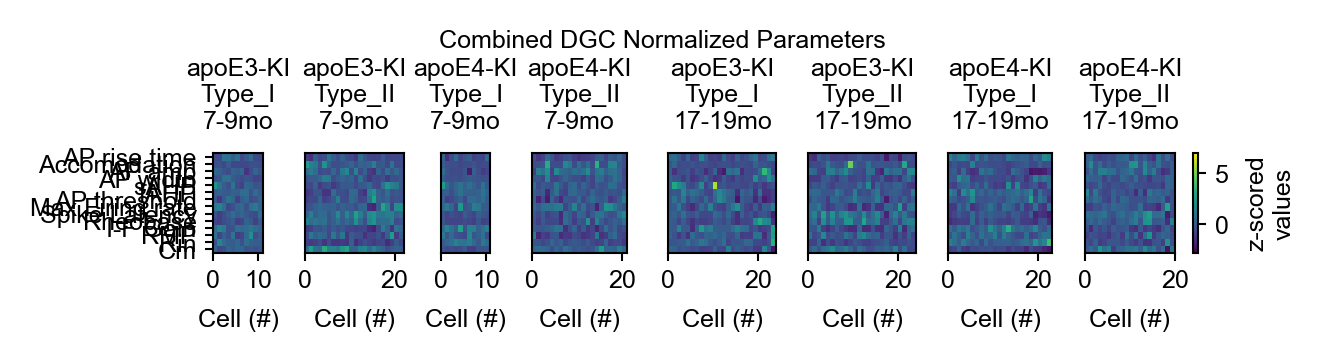

[np.int64(11), np.int64(22), np.int64(11), np.int64(21), np.int64(24), np.int64(24), np.int64(23), np.int64(20)]


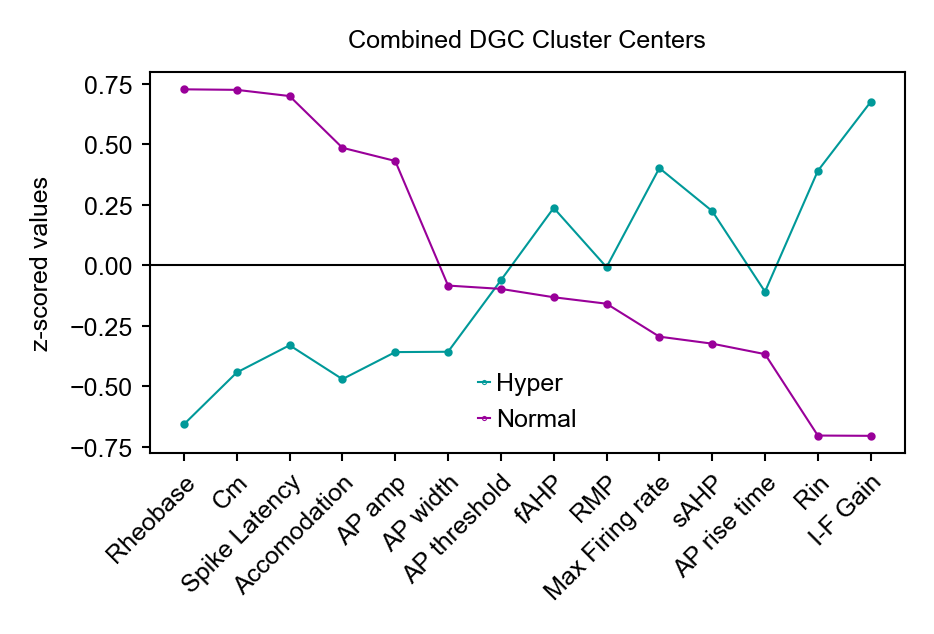

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


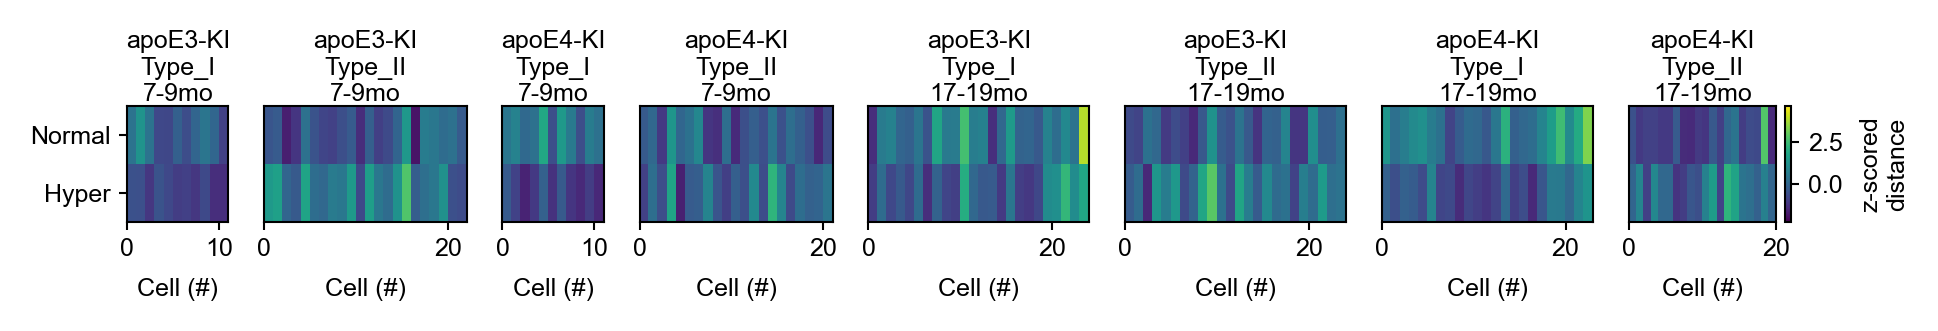

apoE3-KI Type_I 7-9mo [0.01568627450980392, 0.2, 1.0, 1.0]
apoE3-KI Type_II 7-9mo [0, 0.75, 0.75, 1.0]
apoE4-KI Type_I 7-9mo [0.01568627450980392, 0.2, 1.0, 0.6]
apoE4-KI Type_II 7-9mo [0, 0.75, 0.75, 0.6]
apoE3-KI Type_I 17-19mo [1.0, 0.14901960784313725, 0.0, 1.0]
apoE3-KI Type_II 17-19mo [1, 0, 0.65, 1.0]
apoE4-KI Type_I 17-19mo [1.0, 0.14901960784313725, 0.0, 0.6]
apoE4-KI Type_II 17-19mo [1, 0, 0.65, 0.6]
comb_list ['apoE3-KI Type_I 7-9mo', 'apoE3-KI Type_II 7-9mo', 'apoE4-KI Type_I 7-9mo', 'apoE4-KI Type_II 7-9mo', 'apoE3-KI Type_I 17-19mo', 'apoE3-KI Type_II 17-19mo', 'apoE4-KI Type_I 17-19mo', 'apoE4-KI Type_II 17-19mo']
dict_keys(['apoE3-KI Type_I 7-9mo', 'apoE3-KI Type_II 7-9mo', 'apoE4-KI Type_I 7-9mo', 'apoE4-KI Type_II 7-9mo', 'apoE3-KI Type_I 17-19mo', 'apoE3-KI Type_II 17-19mo', 'apoE4-KI Type_I 17-19mo', 'apoE4-KI Type_II 17-19mo'])


,apoE3-KI Type_I 7-9mo,apoE3-KI Type_II 7-9mo,apoE4-KI Type_I 7-9mo,apoE4-KI Type_II 7-9mo,apoE3-KI Type_I 17-19mo,apoE3-KI Type_II 17-19mo,apoE4-KI Type_I 17-19mo,apoE4-KI Type_II 17-19mo
0,1.399848,-2.640761,1.080250,1.277533,-0.494864,-0.759991,1.762926,-0.867188
1,2.510489,-2.619505,2.715007,-0.349679,0.447955,-1.832053,1.392772,-3.304732
2,2.935247,-3.632837,4.048832,-0.934513,2.335093,3.906090,0.984122,0.298706
3,-0.454111,-1.688095,2.678349,-0.694453,0.449108,-1.824212,1.657053,-3.006898
4,0.099761,-1.852974,2.217224,4.218882,1.228593,-2.921709,2.594311,-2.135484


colors_sns [[np.float64(0.01568627450980392), np.float64(0.2), np.float64(1.0), 1.0], [np.float64(0.0), np.float64(0.75), np.float64(0.75), 1.0], [np.float64(0.4094117647058824), np.float64(0.52), np.float64(1.0), 0.6], [np.float64(0.4), np.float64(0.85), np.float64(0.85), 0.6], [np.float64(1.0), np.float64(0.14901960784313725), np.float64(0.0), 1.0], [np.float64(1.0), np.float64(0.0), np.float64(0.65), 1.0], [np.float64(1.0), np.float64(0.4894117647058823), np.float64(0.4), 0.6], [np.float64(1.0), np.float64(0.4), np.float64(0.79), 0.6]] colors_sns
ax_labels Index(['apoE3-KI Type_I 7-9mo', 'apoE3-KI Type_II 7-9mo',
       'apoE4-KI Type_I 7-9mo', 'apoE4-KI Type_II 7-9mo',
       'apoE3-KI Type_I 17-19mo', 'apoE3-KI Type_II 17-19mo',
       'apoE4-KI Type_I 17-19mo', 'apoE4-KI Type_II 17-19mo'],
      dtype='object')
ax_labels_r ['E3-KI\nType I', 'E3-KI\nType II', 'E4-KI\nType I', 'E4-KI\nType II', 'E3-KI\nType I', 'E3-KI\nType II', 'E4-KI\nType I', 'E4-KI\nType II']
segments [np.float

/tmp/ipython-input-1638809457.py:216: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(ax=ax, data=sns_df, palette=colors_sns, scale='area', label=t, inner=None, linewidth=0)
/tmp/ipython-input-1638809457.py:296: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig_distances_split.savefig(f'{folder}/fig_distances_split.'+fig_opt['format'],**fig_opt)
100%|██████████| 1000/1000 [00:09<00:00, 102.63it/s]
/tmp/ipython-input-1754637895.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


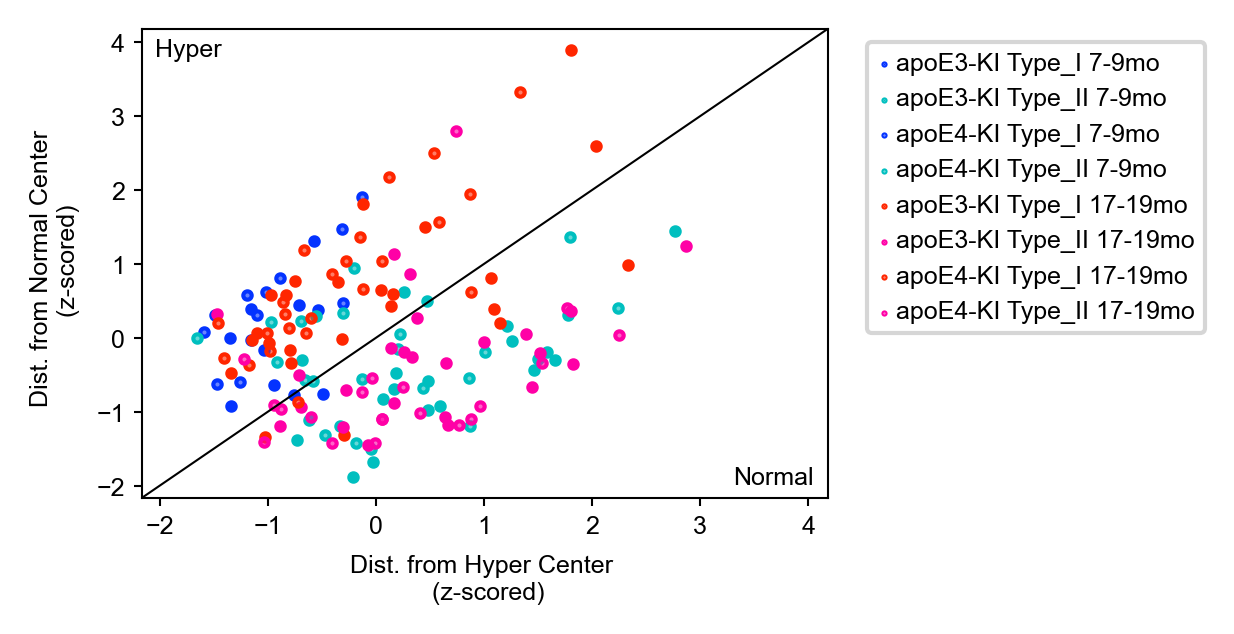

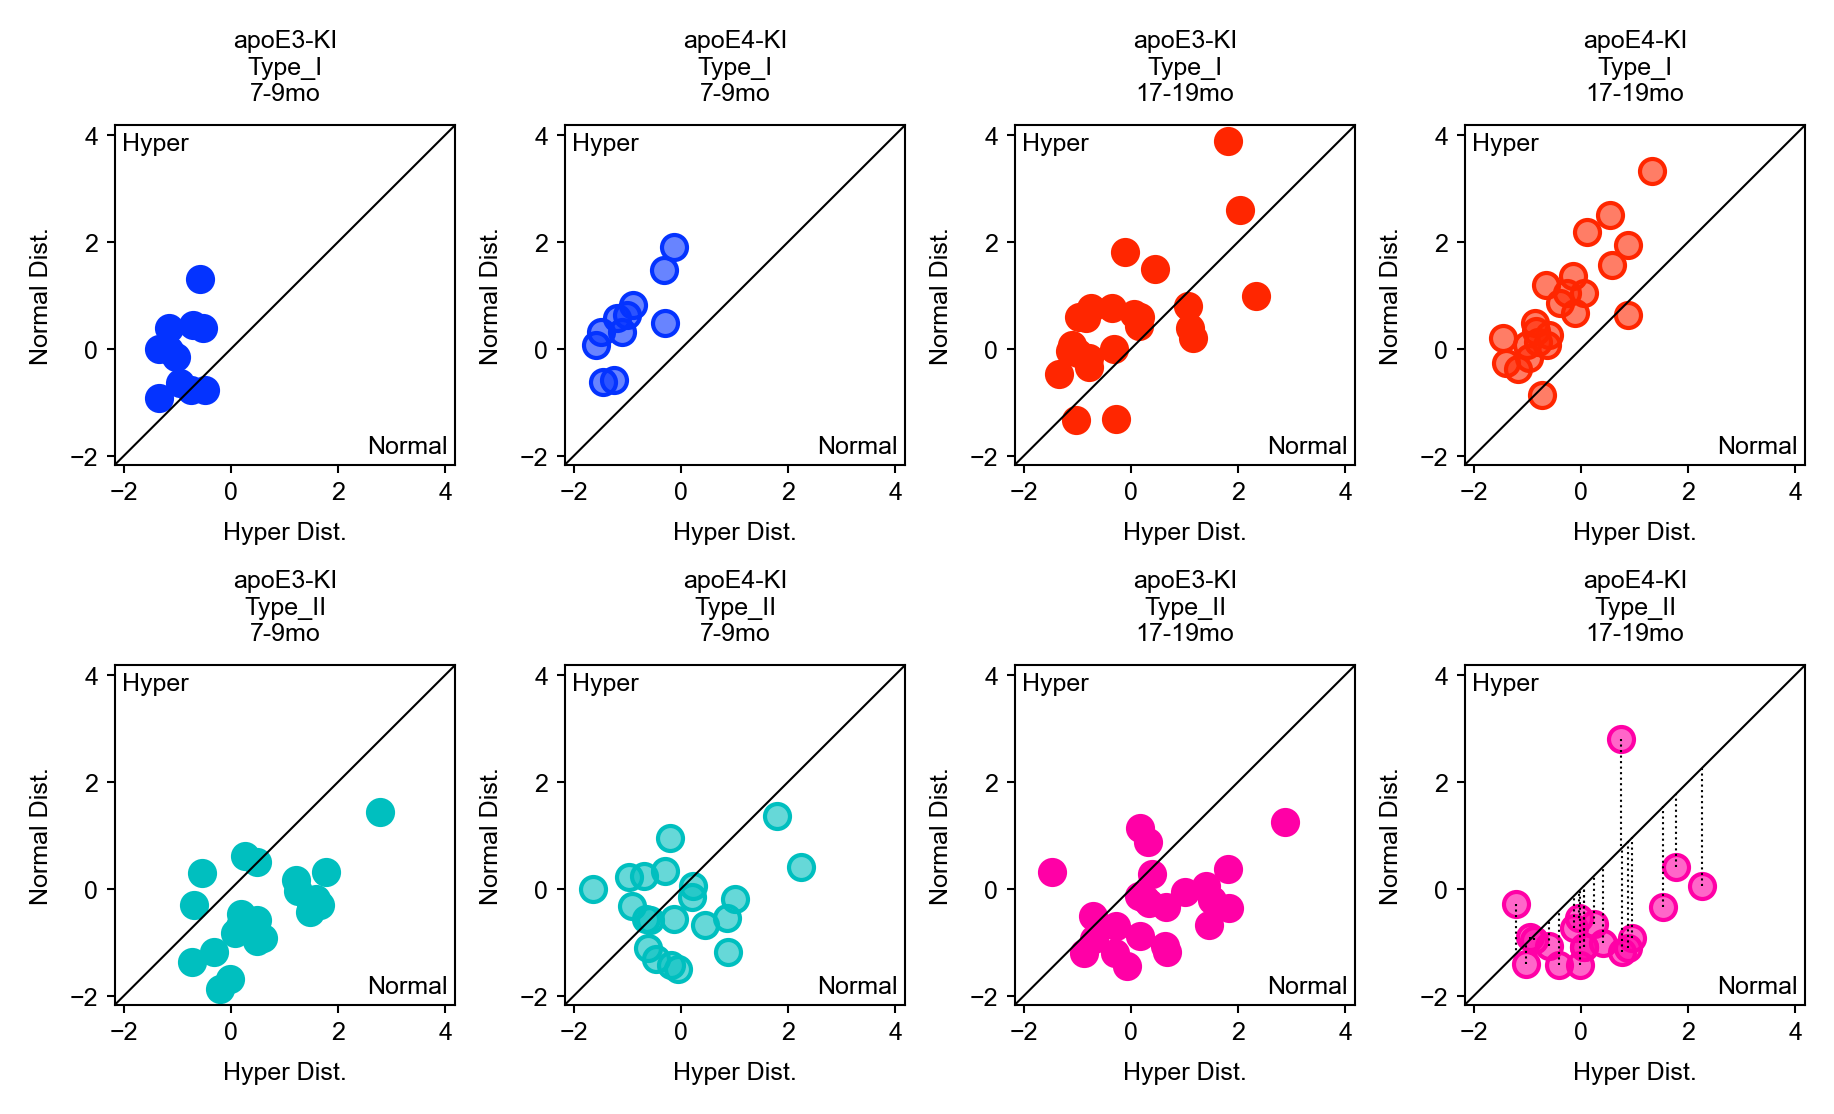

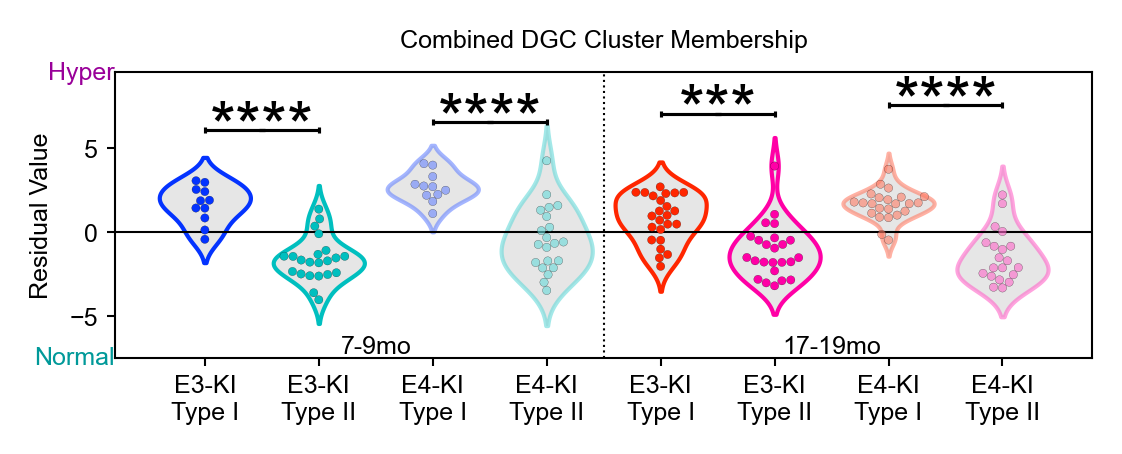

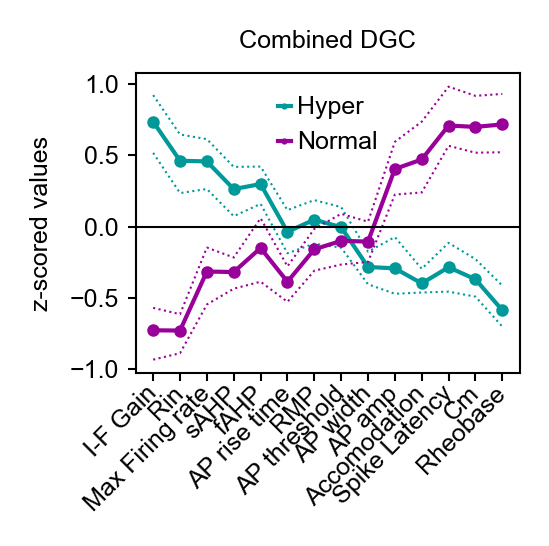

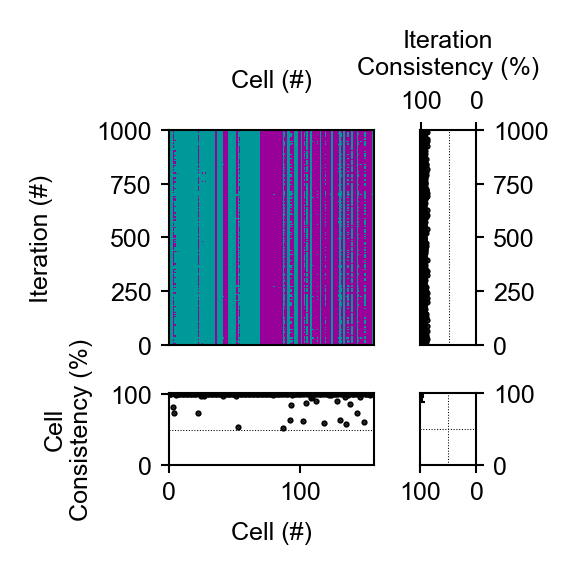

DG_Comb
  adding: DG_Comb/ (stored 0%)
  adding: DG_Comb/CrossVal_Data k=2 Labeling.svg (deflated 88%)
  adding: DG_Comb/GenoType_dist_Separate.svg (deflated 89%)
  adding: DG_Comb/fig_violin_residuals.svg (deflated 77%)
  adding: DG_Comb/CrossVal_Data k=2 Centers.svg (deflated 83%)
  adding: DG_Comb/GenoType_dist.svg (deflated 86%)
  adding: DG_Comb/2W_results Age-Geno.csv (deflated 38%)
  adding: DG_Comb/fig_distances_split.svg (deflated 89%)
  adding: DG_Comb/pairwise Age-Genotype.csv (deflated 72%)
  adding: DG_Comb/Scores.csv (deflated 77%)
  adding: DG_Comb/Normalized_Vals_split.svg (deflated 91%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 450x450 with 0 Axes>

In [30]:
##### DG Combined ####
file_list_DG = [f for f in file_list if 'DG' in f]
print(file_list_DG)
dg_dict={}
for f in file_list_DG:
    f_dict,_=read_data_file(f)
    for k,v in f_dict.items():
        if 'II' in f: k=k.replace('KI','KI Type_II')
        if ' I ' in f: k=k.replace('KI','KI Type_I')
        dg_dict[k]=v

folder ='DG_Comb'
try: os.makedirs(folder)
except: None
full_df = dict_to_df(dg_dict,AP_cut=60)
labeling = ['cell','Cell','type','extra']
numericals, data_for_fit, full_df_no_null = clean_data(labeling, full_df)
type_num, num_t, uniq_types,type_list = get_types(full_df_no_null)
packaged = cluster_full(data_for_fit,folder,numericals)
packaged['cell_type']='Combined DGC'
df_for_34_2W_anova, tukey_data = do_stats(type_list,packaged['score'])


_ = [print(t)for t in uniq_types]

plot_summary_DG_comb(num_t,numericals,type_list,uniq_types,packaged,df_for_34_2W_anova,tukey_data,folder,fig_opt =fig_opt)
packaged['k2_cval'] = cross_val(data_for_fit,numericals,packaged['new_cent_order'],folder,k=2,num_iter = 1000,SubSampleFrac = .8,
            cell_type=packaged['cell_type'],fig_opt =fig_opt,ds_iter=5)
# _ = cross_val(data_for_fit,numericals,packaged['new_cent_order'],folder,k=3,num_iter = 1000,SubSampleFrac = .8,
#             cell_type=packaged['cell_type'],fig_opt =fig_opt,ds_iter=5)
# _ = cross_val(data_for_fit,numericals,packaged['new_cent_order'],folder,k=4,num_iter = 1000,SubSampleFrac = .8,
#             cell_type=packaged['cell_type'],fig_opt =fig_opt,ds_iter=5)
# _ = cross_val(data_for_fit,numericals,packaged['new_cent_order'],folder,k=5,num_iter = 1000,SubSampleFrac = .8,
#             cell_type=packaged['cell_type'],fig_opt =fig_opt,ds_iter=5)
save_dl(folder)

In [31]:
data=packaged

# Create dictionary with features column
df_dict = {'features': data['features']}

# Add a column for each cluster center
for i in range(data['centers'].shape[1]):
    df_dict[f'full_centroid_K{i}'] = data['centers'][:, i]

means = data['k2_cval']['mean_center']
for i in range(means.shape[1]):
    df_dict[f'mean_centroid_K{i}'] = means[:, i]

confidence = data['k2_cval']['confidence']
for i in range(confidence.shape[2]):  # Iterate over clusters (last dimension)
    df_dict[f'confidence_low_K{i}'] = confidence[0, :, i]  # Low bound
    df_dict[f'confidence_high_K{i}'] = confidence[1, :, i]  # High bound

feat_df = pd.DataFrame(df_dict)
feat_df = feat_df.sort_values('full_centroid_K0', ascending=False)
feat_df = feat_df.rename(columns=lambda x: x.replace('K0', 'Hyper').replace('K1', 'Normal'))
feat_df = feat_df.set_index('features')
display(feat_df)
feat_df.to_csv('combined_dgcs.csv')
colab.files.download('combined_dgcs.csv')

,full_centroid_Hyper,full_centroid_Normal,mean_centroid_Hyper,mean_centroid_Normal,confidence_low_Hyper,confidence_high_Hyper,confidence_low_Normal,confidence_high_Normal
features,,,,,,,,
I-F Gain,0.674072,-0.704679,0.737024,-0.730331,0.518299,0.924726,-0.936764,-0.572227
Max Firing rate,0.401000,-0.295131,0.458032,-0.316617,0.263842,0.614769,-0.548718,-0.148187
Rin,0.389468,-0.703493,0.463011,-0.731963,0.235432,0.647644,-0.891505,-0.617186
fAHP,0.236506,-0.132415,0.298855,-0.151031,0.159370,0.422026,-0.388304,0.058636
sAHP,0.223455,-0.324057,0.263300,-0.320337,0.072746,0.419579,-0.437436,-0.218018
RMP,-0.008056,-0.159088,0.048408,-0.160714,-0.120144,0.185820,-0.310764,-0.017185
AP threshold,-0.062295,-0.097911,-0.004873,-0.101035,-0.148518,0.136619,-0.267543,0.089486
AP rise time,-0.109327,-0.367311,-0.037374,-0.388667,-0.188291,0.115201,-0.530311,-0.280704
Spike Latency,-0.330629,0.698373,-0.286608,0.710675,-0.458249,-0.115124,0.568156,0.984200


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

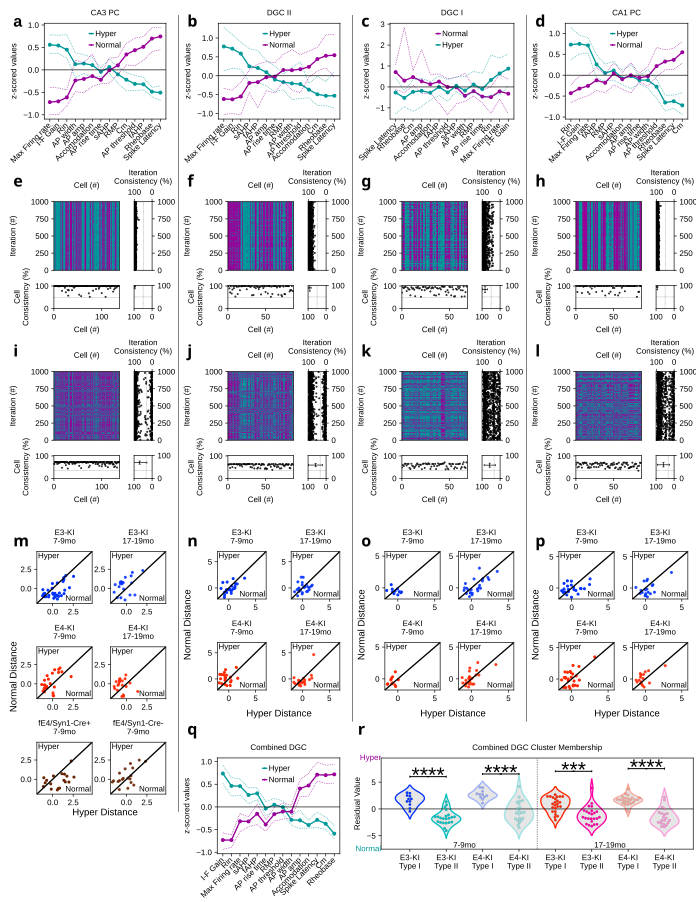

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
## NatAging Resubmission
"""
New Supplemental Figure
"""

row_0 =0
row_1 =row_0+160
row_2 =row_1+170
row_3 = row_2+190
row_4 = row_3+215
dpi = 96
width = 7.25*dpi
length = 9.4*dpi
scale_factor= 1.33
weight='bold'
label_size = 12


sup_layout_1 = Figure(str(width), str(length),
                    Panel(SVG("/content/CA3_parameters_for_PCA_Clean/CrossVal_Data k=2 Centers.svg"),
                    Text("a", 10, 20, size=label_size,weight=weight,font='arial')
                    ).scale(scale_factor).move(width*0, row_0),
                    Panel(SVG("/content/DG_Type_II_GC_main_parameters_Clean/CrossVal_Data k=2 Centers.svg"),
                    Text("b", 10, 20, size=label_size,weight=weight)
                    ).scale(scale_factor).move(width*.25, row_0),
                    Panel(SVG("/content/DG_Type_I_GC_main_parameters_Clean/CrossVal_Data k=2 Centers.svg"),
                    Text("c", 10, 20, size=label_size,weight=weight)
                    ).scale(scale_factor).move(width*.50, row_0),
                    Panel(SVG("/content/CA1_main_parameters_Clean/CrossVal_Data k=2 Centers.svg"),
                    Text("d", 10, 20, size=label_size,weight=weight)
                    ).scale(scale_factor).move(width*.75, row_0),


                    Panel(SVG("/content/CA3_parameters_for_PCA_Clean/CrossVal_Data k=2 Labeling.svg"),
                    Text("e", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*0, row_1),
                    Panel(SVG("/content/DG_Type_II_GC_main_parameters_Clean/CrossVal_Data k=2 Labeling.svg"),
                    Text("f", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.25, row_1),
                    Panel(SVG("/content/DG_Type_I_GC_main_parameters_Clean/CrossVal_Data k=2 Labeling.svg"),
                    Text("g", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.50, row_1),
                    Panel(SVG("/content/CA1_main_parameters_Clean/CrossVal_Data k=2 Labeling.svg"),
                    Text("h", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.75, row_1),

                    Panel(SVG("/content/CA3_parameters_for_PCA_Clean/CrossVal_Data k=3 Labeling.svg"),
                    Text("i", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.0, row_2),
                    Panel(SVG("/content/DG_Type_II_GC_main_parameters_Clean/CrossVal_Data k=3 Labeling.svg"),
                    Text("j", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.25, row_2),
                    Panel(SVG("/content/DG_Type_I_GC_main_parameters_Clean/CrossVal_Data k=3 Labeling.svg"),
                    Text("k", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.50, row_2),
                    Panel(SVG("/content/CA1_main_parameters_Clean/CrossVal_Data k=3 Labeling.svg"),
                    Text("l", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.75, row_2),

                    Panel(SVG("/content/CA3_parameters_for_PCA_Clean/GenoType_dist_Separate.svg"),
                    Text("m", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*0-0, row_3),
                    Panel(SVG("/content/DG_Type_II_GC_main_parameters_Clean/GenoType_dist_Separate.svg"),
                    Text("n", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.25, row_3),
                    Panel(SVG("/content/DG_Type_I_GC_main_parameters_Clean/GenoType_dist_Separate.svg"),
                    Text("o", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.5, row_3),
                    Panel(SVG("/content/CA1_main_parameters_Clean/GenoType_dist_Separate.svg"),
                    Text("p", 10, 20, size=label_size, weight=weight)
                    ).scale(scale_factor).move(width*.75, row_3),

                    Panel(SVG("//content/DG_Comb/CrossVal_Data k=2 Centers.svg"),
                    Text("q", 10, 0, size=label_size,weight=weight)
                    ).scale(scale_factor).move(width*.25, row_4),

                    Panel(SVG("/content/DG_Comb/fig_violin_residuals.svg"),
                    Text("r", 10, 0, size=label_size,weight=weight)
                    ).scale(scale_factor).move(width*.495, row_4),


                    # Add vertical dividing lines
                    Line(points=[(width * 0.25+4.5, 15), (width * 0.25+4.5, length*.9)], width=1, color='grey'),
                    Line(points=[(width * 0.50+4.5, 15), (width * 0.5+4.5, length*.8)], width=1, color='grey'),
                    Line(points=[(width * 0.75+4.5, 15), (width * 0.75+4.5, length*.8)], width=1, color='grey'),

            )


sup_layout_1.save(f"SupFig4_v2.svg")
display(sup_layout_1)
colab.files.download(f"SupFig4_v2.svg")

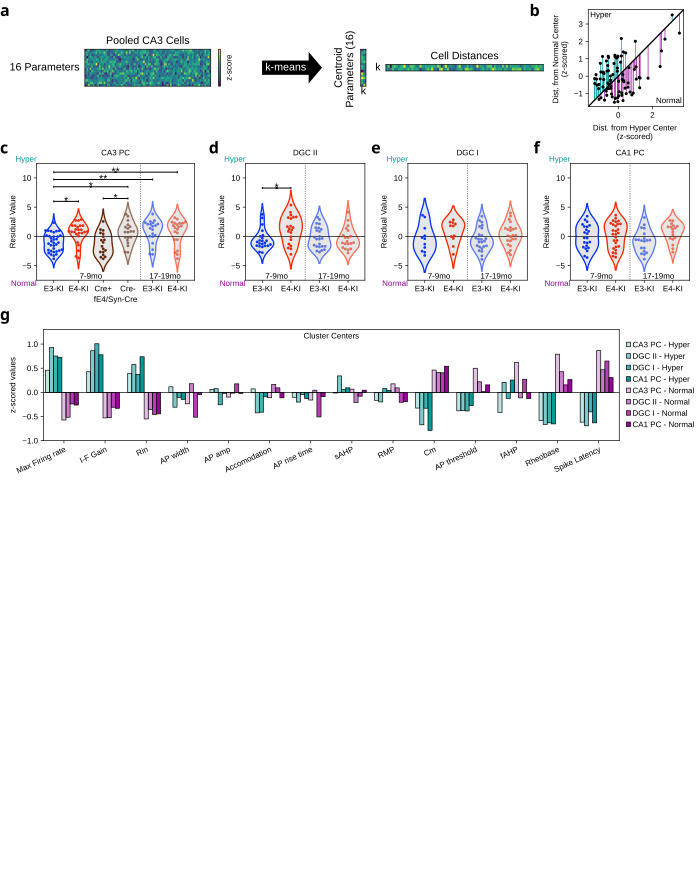

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
# fig_cartoon_x(fig_opt={'dpi': 300, 'format':'svg','bbox_inches':None})


######### Alt fig 5

left_margin = 0
row_0 = 0
row_0_5 =row_0+20
row_1 =row_0+140
row_2 =row_1+180
dpi = 96
width = 7.25*dpi
length = 9.25*dpi
scale_factor= 1.333
weight='bold'
label_size = 12

weight = 'bold'
# label_size = label_size*scale
#### from svgutils.compose import *

CONFIG = {
    "svg.file_path": ".",
    "figure.save_path": ".",
    "image.file_path": ".",
    "text.position": (0, 0),
    "text.weight": "bold",
    "text.font": "Arial",
}


layout_1 = Figure(width,length,
        Panel(SVG("/content/fig_cartoon_x.svg"),
              Text("a", 0, 12-20, size=label_size, weight=weight)
             ).move(width*.0, row_0_5).scale(scale_factor),

        Panel(SVG("/content/CA1_main_parameters_Clean/GenoType_dist.svg"),
              Text("b", -10, 12, size=label_size, weight=weight)
             ).scale(scale_factor).move(width*.78, row_0),

        Panel(SVG("/content/CA3_parameters_for_PCA_Clean/fig_violin_residuals.svg"),
              Text("c", 0, 10, size=label_size, weight=weight)
             ).scale(scale_factor).move(width*0, row_1),
        Panel(SVG("/content/DG_Type_II_GC_main_parameters_Clean/fig_violin_residuals.svg"),
              Text("d", 0, 10, size=label_size, weight=weight)
             ).scale(scale_factor).move(width*.3+width*(.7/3*0), row_1),
        Panel(SVG("/content/DG_Type_I_GC_main_parameters_Clean/fig_violin_residuals.svg"),
              Text("e", 0, 10, size=label_size, weight=weight)
             ).scale(scale_factor).move(width*.3+width*(.7/3*1), row_1),
        Panel(SVG("/content/CA1_main_parameters_Clean/fig_violin_residuals.svg"),
              Text("f", 0, 10, size=label_size, weight=weight)
             ).scale(scale_factor).move(width*.3+width*(.7/3*2), row_1),

        Panel(SVG("/content/combined_centers.svg"),
              Text("g", 0, 0, size=label_size, weight=weight)
             ).scale(scale_factor).move(left_margin+0, row_2),

        )



display(layout_1)
layout_1.save("Figure_5_v2.svg")
colab.files.download('Figure_5_v2.svg')


In [61]:
# print(multipack.keys())

# X = multipack['CA3 PC']['data_for_fit']
# X.shape

# from scipy.cluster.hierarchy import linkage, dendrogram
# from scipy.spatial.distance import pdist

# # Perform hierarchical clustering on observations (rows)
# linkage_matrix = linkage(X, method='ward')

# # Get the optimal ordering from the dendrogram
# dendro = dendrogram(linkage_matrix, no_plot=True)
# optimal_order = dendro['leaves']

# # Sort X by this ordering
# X_sorted = X[optimal_order, :]

# # autocorr = np.corrcoef(X)
# autocorr_sorted = np.corrcoef(X_sorted)
# fig,ax=plt.subplots(1,1,figsize=(1.2,1))
# cb=ax.pcolorfast(autocorr_sorted,cmap='RdBu_r',vmin=-1,vmax=1)
# plt.colorbar(cb)